# Análisis FBG PEEK-4: 3 Sensores (11/06/2026)

✅ **Fibra PEEK-4 con 3 sensores FBG funcionales**

Este notebook analiza **sensores FBG** de la fibra PEEK-4 (2 polarizaciones cada uno, medición del 11-06-2026).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.

## 📋 Configuración:
- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, 6-7 cápsula fibra
- **3 FBGs funcionales**: FBG-1, FBG-2, FBG-3 (cada uno con polarización P y S)
- **Fibra**: PEEK-7 con 450µm de diámetro
- **Análisis**: Media de polarizaciones vs temperatura
- **Plateaus**: Definición manual opcional
- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente)

## 💡 Notas sobre el flujo de trabajo:
1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.
2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible, permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/.venv-fbg/bin/python
Python versión: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

### 🔍 Listar Archivos Disponibles (Opcional)

Si no estás seguro de qué archivos ROOT existen en el directorio, ejecuta esta celda para listarlos.

In [3]:
from zoneinfo import ZoneInfo
TZ_VALENCIA = ZoneInfo("Europe/Madrid")

# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260617.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
TIME_SHIFT = datetime.timedelta(hours=0)  # ✅ Ya no necesitamos shift, los conversores están arreglados

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

try:
    with uproot.open(filepath) as file:
        print(f"✓ Trees disponibles: {file.keys()}")
        peak_data = file["peak"].arrays(library="np")
        temp_data = file["temp"].arrays(library="np")
    
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    times_peak_raw = peak_data["t"][:, 0]
    times_temp_raw = temp_data["t"]
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    temp_raw = temp_data["temp"]
    # press_raw = press_data["press"]
    
    print(f"\n✅ Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    print(f"   • Temperature: {temp_raw.shape}")
    
    # ✅ fromtimestamp + zona Valencia en lugar de utcfromtimestamp
    times_peak_original = np.array([
        datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None)
        for t in times_peak_raw
    ])
    times_temp = np.array([
        datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None)
        for t in times_temp_raw
    ])
    
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"\n🔴 TEMPERATURA:")
    print(f"   Inicio: {times_temp[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_temp[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    diff_inicio = (times_temp[0] - times_peak_original[0]).total_seconds() / 3600
    diff_fin = (times_temp[-1] - times_peak_original[-1]).total_seconds() / 3600
    
    print(f"\n⚠️  DESFASE DETECTADO:")
    print(f"   Temperatura START - Wavelength START: {diff_inicio:+.2f} horas")
    print(f"   Temperatura END - Wavelength END: {diff_fin:+.2f} horas")
    
    if abs(diff_inicio) > 0.5 or abs(diff_fin) > 0.5:
        print(f"\n💡 RECOMENDACIÓN:")
        print(f"   Los datos parecen tener un desfase temporal.")
        if diff_inicio > 0:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours={abs(diff_inicio):.0f})")
        else:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours=-{abs(diff_inicio):.0f})")
        print(f"   Luego re-ejecuta esta celda.")
    else:
        print(f"\n✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)")
    
    # Aplicar TIME_SHIFT (ahora es 0, pero se mantiene la lógica por si acaso)
    times_peak = times_peak_original + TIME_SHIFT
    times_raw = times_peak_raw
    times_all = times_peak
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")

except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260617.root
⏱️  TIME_SHIFT configurado: 0.0 horas
✓ Trees disponibles: ['peak;6', 'temp;6']

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (320375, 2)
   wav: shape = (320375, 2, 3)
   sweep: shape = (320375, 2, 3)
   ch: shape = (320375, 3)
   pos: shape = (320375, 3)

✅ Datos cargados correctamente
   • Wavelength: (320375, 2, 3)
   • Wavelength range: [1533.80, 1542.64] nm
   • Temperature: (1467, 8)

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-06-17 11:34:02
   Fin:    2026-06-17 16:36:29

🔴 TEMPERATURA:
   Inicio: 2026-06-17 11:33:09
   Fin:    2026-06-17 16:35:59

⚠️  DESFASE DETECTADO:
   Temperatura START - Wavelength START: -0.01 horas
   Temperatura END - Wavelength END: -0.01 horas

✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)


## 3️⃣ Filtrar Rango Temporal (16:00-17:30)

In [4]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Opción A: Usar TODO el rango disponible
use_full_range = False  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    fecha = datetime.date(2026, 6, 17)  # ⬅️ CAMBIAR según tu archivo (20260609.root)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(10, 0))
    t_fin = datetime.datetime.combine(fecha, datetime.time(13, 0))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura usando sus propios tiempos (sin shift)
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos en el rango: {len(times_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")
    print(f"   2. O ajusta 't_inicio' y 't_fin' según el rango disponible (ver arriba)")

📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-06-17 11:34:02
   Fin:    2026-06-17 16:36:29

✅ Rango seleccionado para análisis:
   2026-06-17 10:00 - 13:00
   Puntos en el rango: 219,873


## 4️⃣ Análisis de Temperatura (8 RTDs)

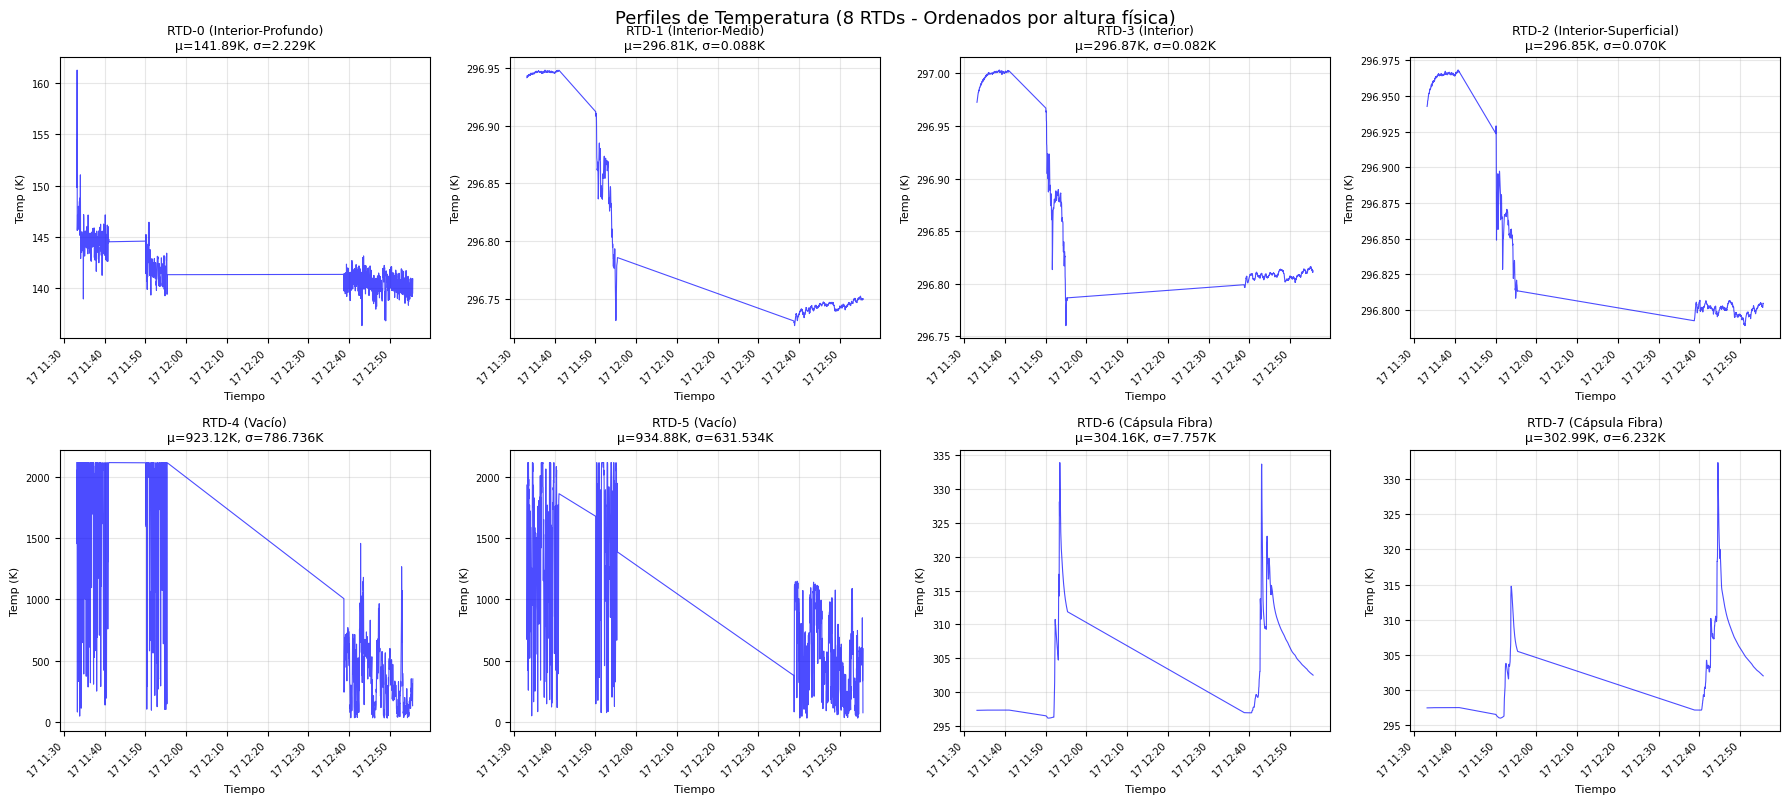


📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Profundo)     : μ=141.89K  σ= 2.229K
RTD-1 (Interior-Medio)        : μ=296.81K  σ= 0.088K
RTD-3 (Interior)              : μ=296.87K  σ= 0.082K
RTD-2 (Interior-Superficial)  : μ=296.85K  σ= 0.070K
RTD-4 (Vacío)                 : μ=923.12K  σ=786.736K
RTD-5 (Vacío)                 : μ=934.88K  σ=631.534K
RTD-6 (Cápsula Fibra)         : μ=304.16K  σ= 7.757K
RTD-7 (Cápsula Fibra)         : μ=302.99K  σ= 6.232K


In [5]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Profundo)"),      # Más cercano al suelo
    (1, "RTD-1 (Interior-Medio)"),         # Medio
    (3, "RTD-3 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Vacío)"),                  # Vacío
    (6, "RTD-6 (Cápsula Fibra)"),          # Dentro de cápsula
    (7, "RTD-7 (Cápsula Fibra)")           # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name}\nμ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel('Tiempo', fontsize=8)
        axes[idx].set_ylabel('Temp (K)', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.suptitle('Perfiles de Temperatura (8 RTDs - Ordenados por altura física)', fontsize=13, y=1.00)
plt.show()

print("\n📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")

## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [6]:
# ⚠️ CONFIGURACIÓN: Solo 2 sensores funcionales
# 2 sensores × 2 polarizaciones = 4 canales
# Índices 0-based: sensor 0, 1 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
    {"pol": 0, "sensor": 2, "label": "FBG-3-P"},
    {"pol": 1, "sensor": 2, "label": "FBG-3-S"}
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (2 sensores × 2 polarizaciones)")

✅ Configurados 6 canales FBG (2 sensores × 2 polarizaciones)


### 5.2 Filtrado Wavelength (μ±3σ)

In [7]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0):
    """Filtra wavelength usando método μ±3σ"""
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - sigma_threshold * std_wav
    threshold_max = mean_wav + sigma_threshold * std_wav
    
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (solo sensores funcionales: 0, 1)
print(f"\n🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2):")
for sensor_idx in range(2):  # Solo 0, 1 (FBG-3 OMITIDO)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar solo canales configurados (FBG-4 excluido)
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(wav_data, times_filtered)

print("\n✅ Filtrado completado (solo sensores funcionales)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (219873, 2, 3)
   Dimensiones: (time=219873, pol=2, sensor=3)

🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2):
   FBG-1-P:  219873 pts > 0, range=[1533.80, 1534.91] nm, μ=1534.33 nm
   FBG-1-S:  219873 pts > 0, range=[1534.03, 1535.02] nm, μ=1534.35 nm
   FBG-2-P:  219873 pts > 0, range=[1537.46, 1539.12] nm, μ=1537.73 nm
   FBG-2-S:  219873 pts > 0, range=[1537.46, 1539.11] nm, μ=1537.73 nm

✅ Filtrado completado (solo sensores funcionales)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1534.330407  0.246633     219873
FBG-1-S      1534.347226  0.230137     219873
FBG-2-P      1537.731228  0.244505     215654
FBG-2-S      1537.731530  0.243990     215691
FBG-3-P      1540.865675  0.294008     218014
FBG-3-S      1540.985803  0.219567     216415


### 5.3 Calcular Media de Polarizaciones

In [8]:
# Calcular media P+S para cada sensor (solo sensores funcionales: 1, 2)
# FBG-3 omitido (sin datos)
fbg_mean_data = {}

for sensor_num in [1, 2, 3]:  # Solo sensores funcionales (FBG-3 excluido)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para sensores funcionales")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6f} {data['std']:<15.6f} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para sensores funcionales

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1534.338817     0.235851        219873
FBG-2-Mean      1537.712103     0.201659        215654
FBG-3-Mean      1540.916671     0.222073        218014


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

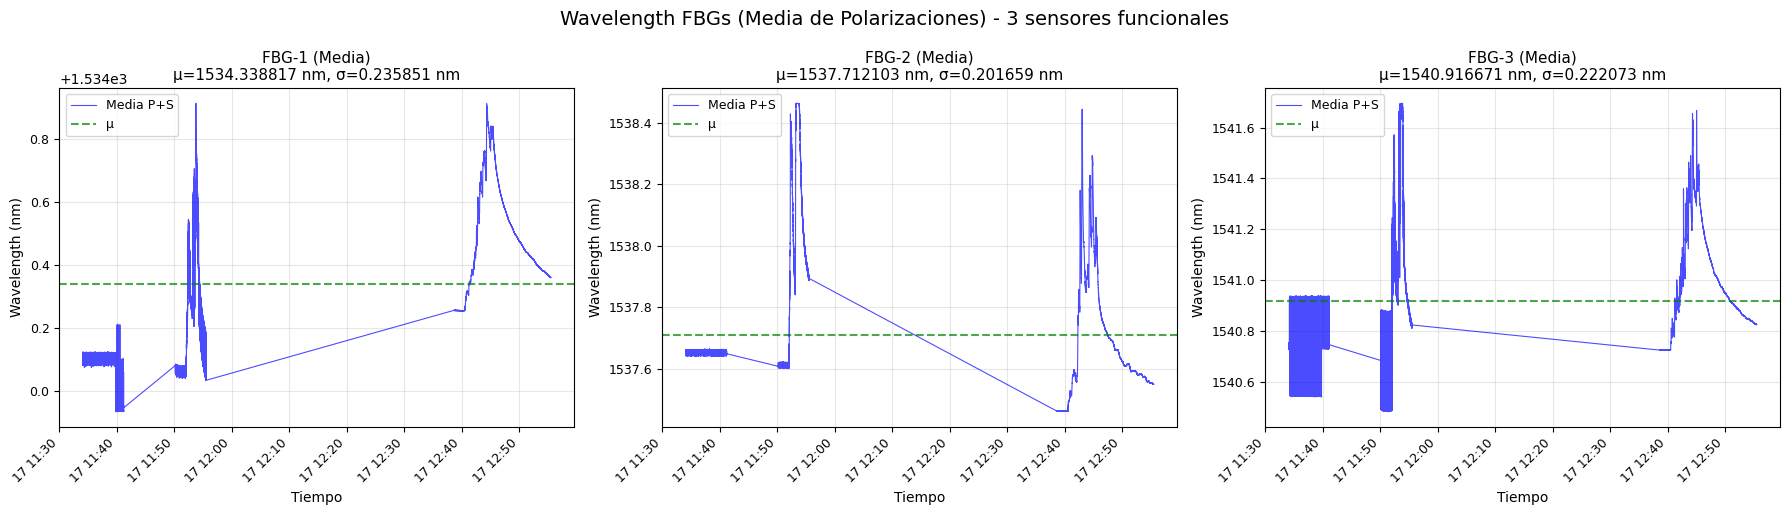

In [9]:
# Ajustar layout para 2 sensores (FBG-3 omitido)
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.6f} nm, σ={data['std']:.6f} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores funcionales', fontsize=14, y=1.02)
plt.show()

## 6️⃣ Correlación Temperatura - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [10]:
# Usar RTD-8 (cápsula fibra) como referencia
rtd_ref_idx = 7  # RTD-8 (cápsula fibra) es el sensor 7 (índice 7 en Python)
rtd_ref_name = "RTD-8 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

print(f"✅ Referencia: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")

✅ Referencia: RTD-8 (Cápsula)
   Rango: [295.94, 332.40] K


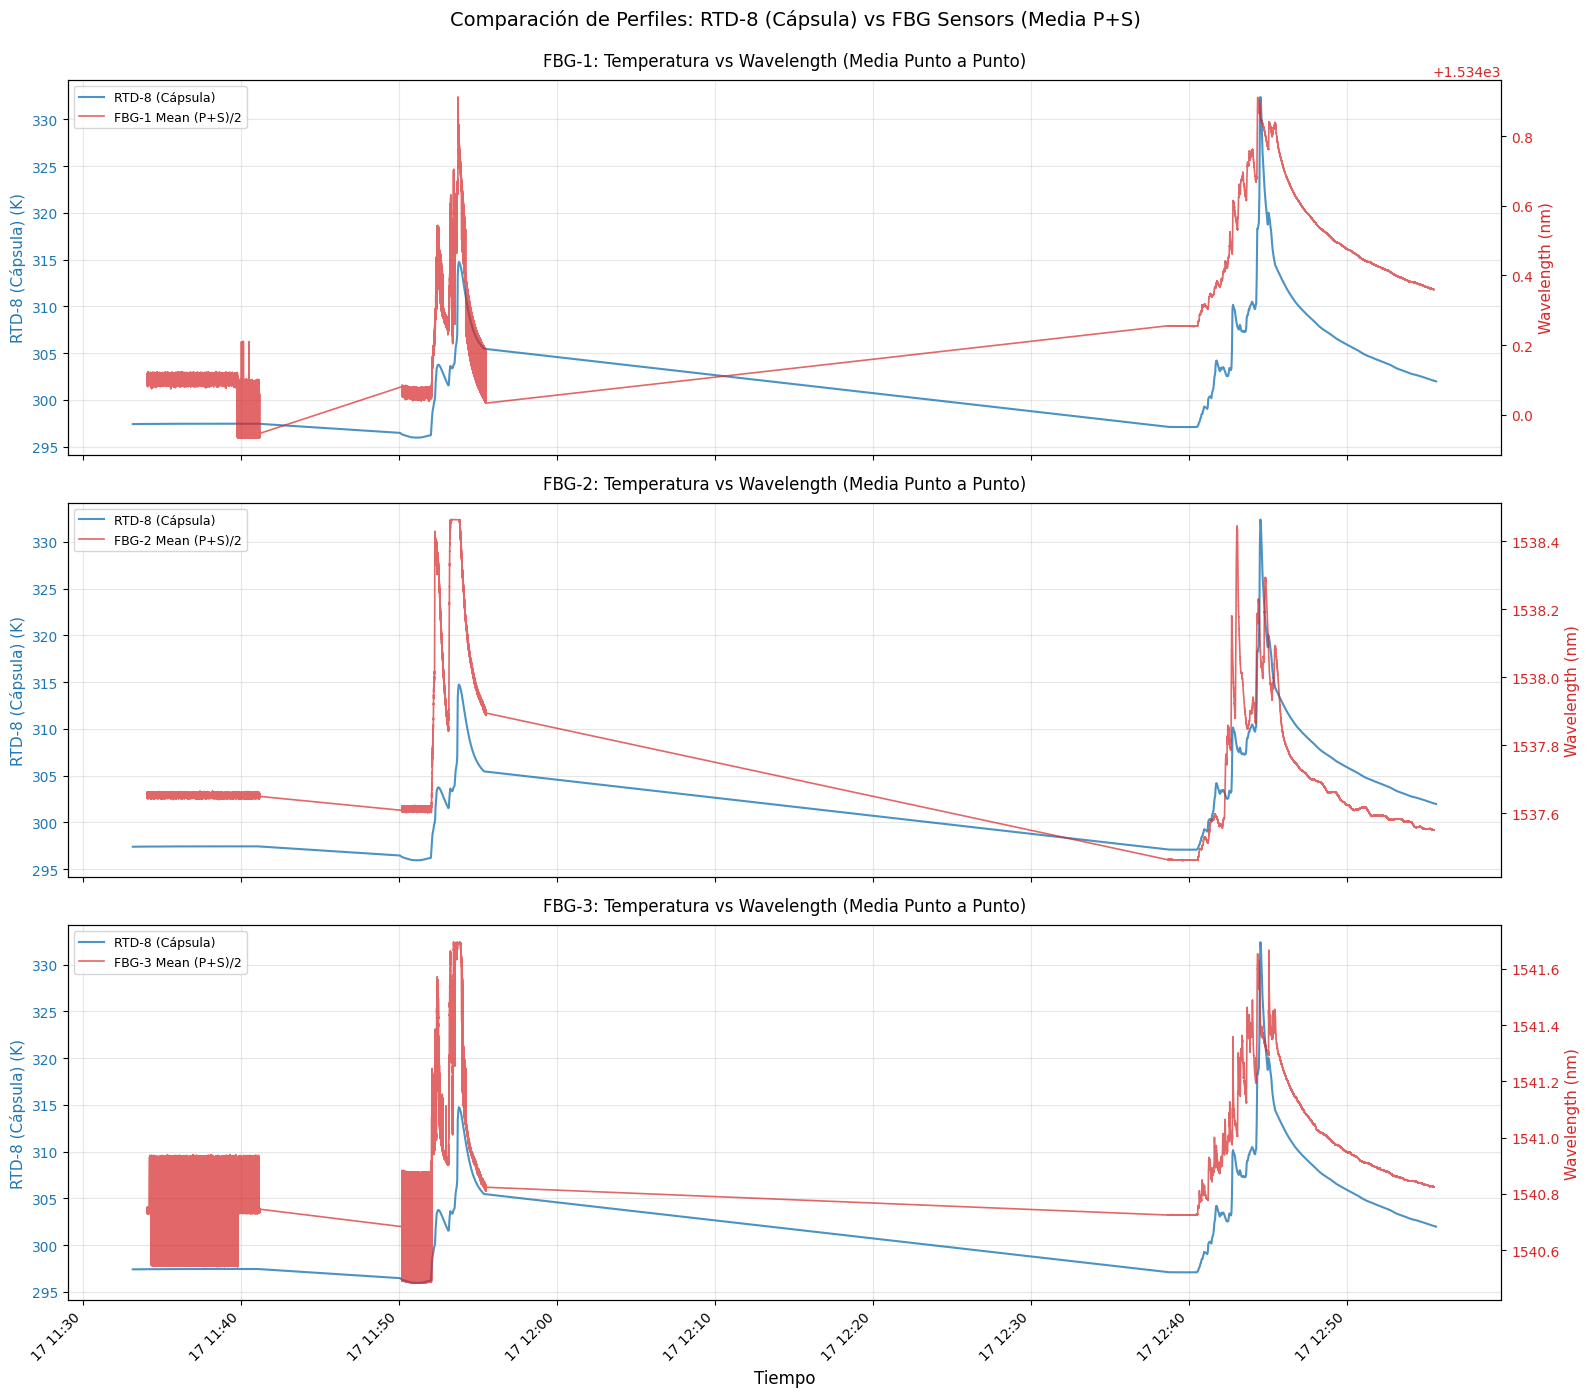

✅ Gráficos superpuestos generados para 3 sensores FBG
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [11]:
# Superposición de temperatura con cada sensor FBG (3 subplots)
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

color_temp = 'tab:blue'
color_wav = 'tab:red'

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    fbg_data_plot = fbg_mean_data[fbg_label]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho: Wavelength (media punto a punto P+S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=11, color=color_wav)
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.7, 
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + custom_lines, 
                  labels1 + labels2 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num}: Temperatura vs Wavelength (Media Punto a Punto)', 
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación de Perfiles: {rtd_ref_name} vs FBG Sensors (Media P+S)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para 3 sensores FBG")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")

### 6.2 Visualización de Perfiles (para definir plateaus)

Superposición de temperatura y wavelength para identificar visualmente los plateaus.

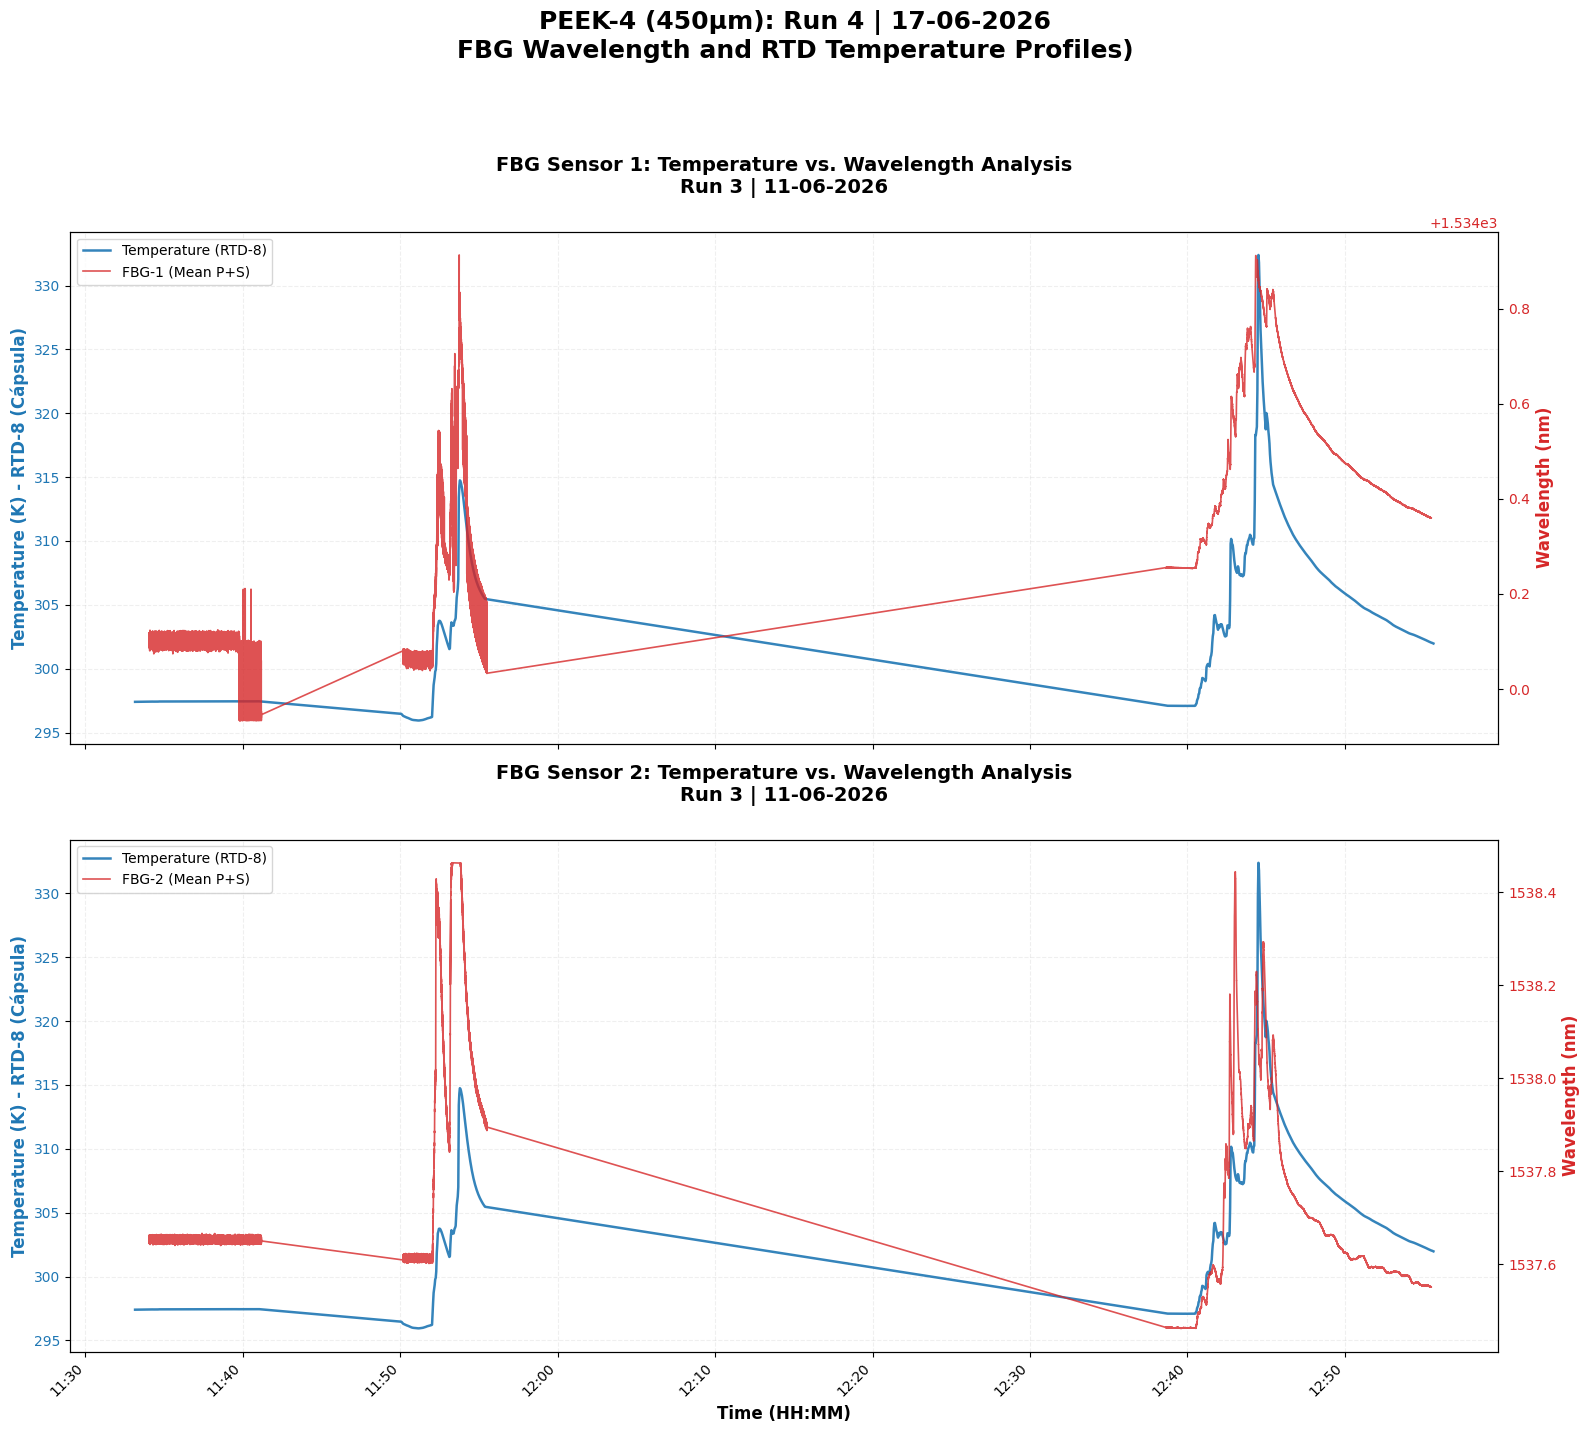

✅ Plot generated with English labels and shaded plateaus.


In [12]:
# ============================================================================
# PLOT: Wavelength vs Temperature with Shaded Plateaus (English)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_wav = 'tab:red'
# Colors for the plateau shaded areas
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue
        
    fbg_data_plot = fbg_mean_data[fbg_label]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD-8 Capsule)
    ax1.set_ylabel(f'Temperature (K) - {rtd_ref_name}', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.8, alpha=0.9, label='Temperature (RTD-8)')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')
    

    # 3. Right Axis: Wavelength
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color=color_wav, fontweight='bold')
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.8, 
             label=f'FBG-{sensor_num} (Mean P+S)')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: Temperature vs. Wavelength Analysis\nRun 3 | 11-06-2026', 
                  fontsize=14, pad=28, fontweight='bold')
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.8)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Shared Layout
plt.suptitle('PEEK-4 (450µm): Run 4 | 17-06-2026\nFBG Wavelength and RTD Temperature Profiles)', 
             fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.975])
plt.show()

print("✅ Plot generated with English labels and shaded plateaus.")

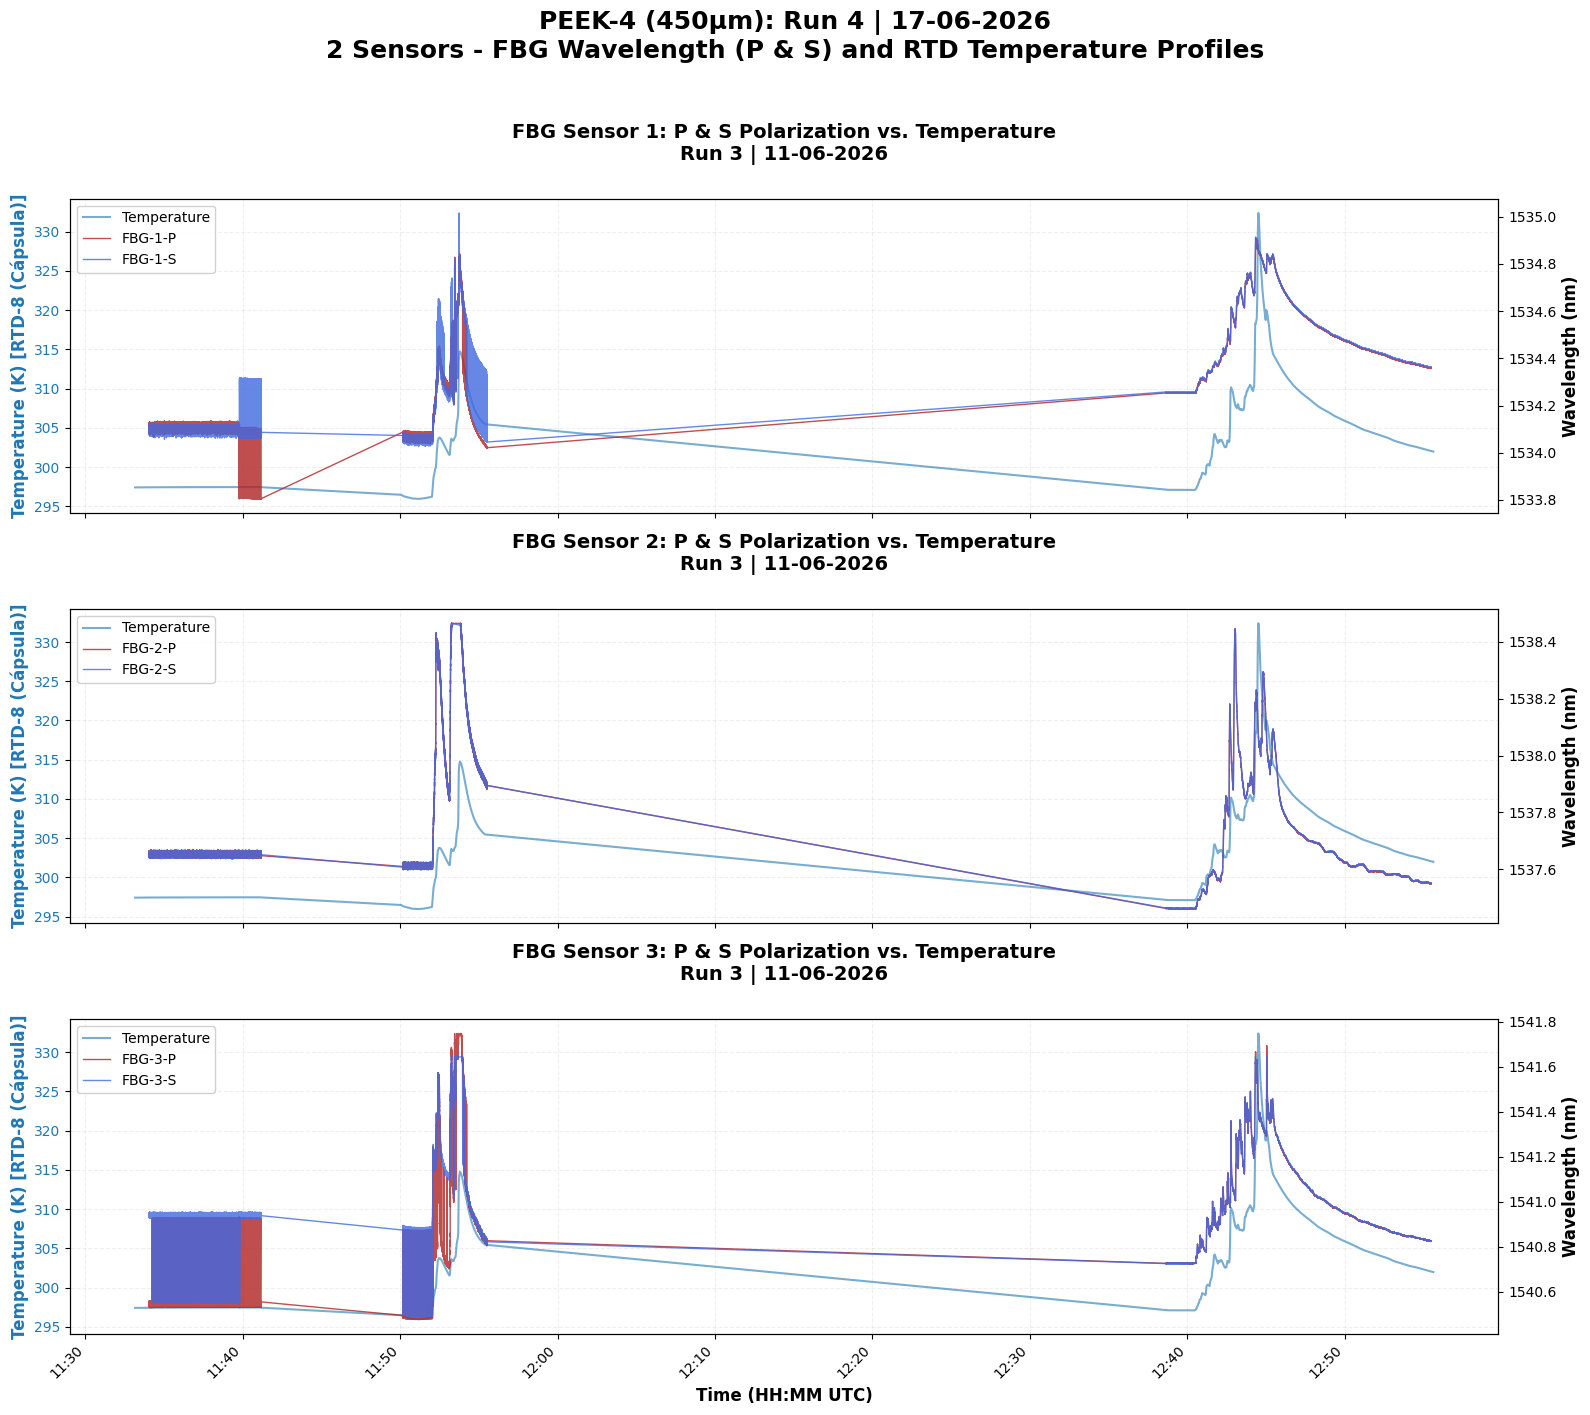

✅ Superimposed polarization plot generated.


In [13]:
# ============================================================================
# PLOT: Dual Polarization (P & S) vs Temperature with Shaded Plateaus
# Fiber: PEEK-4 (450µm) | Run 4 | 17-06-2026
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   # Color for Polarization P
color_pol_s = 'royalblue'   # Color for Polarization S
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

for idx, sensor_num in enumerate([1, 2, 3]):
    # Labels for both polarizations
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    
    if label_p not in fbg_filtered_data or label_s not in fbg_filtered_data:
        print(f"⚠️ Data missing for {label_p} or {label_s}, skipping...")
        continue
        
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD Reference)
    ax1.set_ylabel(f'Temperature (K) [{rtd_ref_name}]', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.6, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')
    

    # 3. Right Axis: Wavelength (Superimposed Polarizations)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color='black', fontweight='bold')
    
    # Plot P Polarization
    ax2.plot(data_p["timestamps"], data_p["wavelength"], 
             color=color_pol_p, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-P')
    
    # Plot S Polarization
    ax2.plot(data_s["timestamps"], data_s["wavelength"], 
             color=color_pol_s, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-S')
    
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.ticklabel_format(useOffset=False, axis='y') # Crucial to see pm changes
    
    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: P & S Polarization vs. Temperature\nRun 3 | 11-06-2026',                  fontsize=14, pad=28, fontweight='bold')
    
    # Merge legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.9)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Overall Figure Title
plt.suptitle('PEEK-4 (450µm): Run 4 | 17-06-2026\n2 Sensors - FBG Wavelength (P & S) and RTD Temperature Profiles', 
             fontsize=18, y=0.97, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("✅ Superimposed polarization plot generated.")

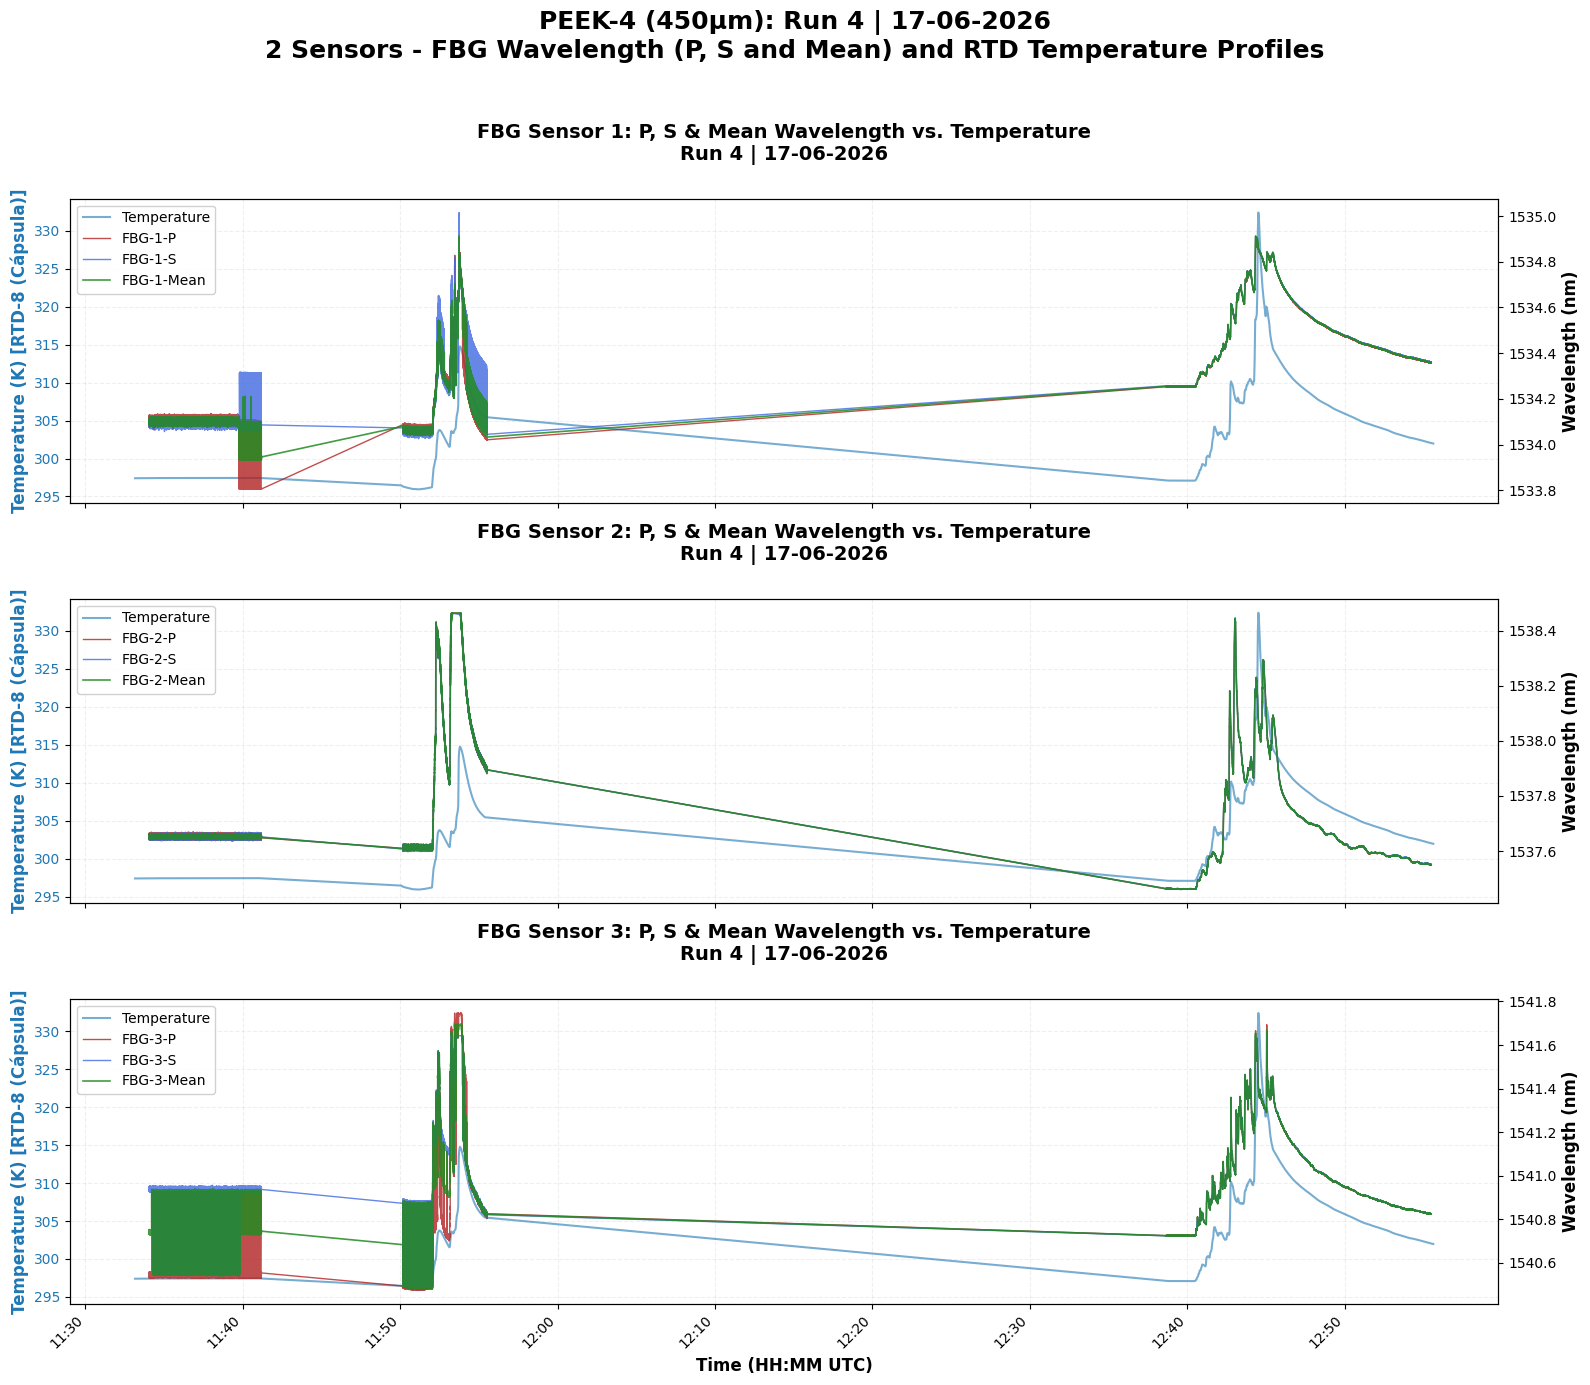

✅ Combined P/S/Mean plot generated.


In [14]:
# ============================================================================
# PLOT: P, S y Media vs Temperatura con Plateaus Sombreados
# Fiber: PEEK-4 (450µm) | Run 4 | 17-06-2026
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   # Color for Polarization P
color_pol_s = 'royalblue'   # Color for Polarization S
color_pol_mean = 'forestgreen'  # Color for Mean (P+S)/2
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

for idx, sensor_num in enumerate([1, 2, 3]):
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"

    if (
        label_p not in fbg_filtered_data or
        label_s not in fbg_filtered_data or
        label_mean not in fbg_mean_data
    ):
        print(f"⚠️ Data missing for {label_p}, {label_s} or {label_mean}, skipping...")
        continue

    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    data_mean = fbg_mean_data[label_mean]
    ax1 = axes[idx]

    # 1. Left Axis: Temperature (RTD Reference)
    ax1.set_ylabel(f'Temperature (K) [{rtd_ref_name}]', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.6, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')

    # 3. Right Axis: Wavelength (P, S and Mean)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color='black', fontweight='bold')

    ax2.plot(data_p["timestamps"], data_p["wavelength"],
             color=color_pol_p, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-P')
    ax2.plot(data_s["timestamps"], data_s["wavelength"],
             color=color_pol_s, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-S')
    ax2.plot(data_mean["timestamps"], data_mean["wavelength"],
             color=color_pol_mean, linewidth=1.2, alpha=0.85, label=f'FBG-{sensor_num}-Mean')

    ax2.tick_params(axis='y', labelcolor='black')
    ax2.ticklabel_format(useOffset=False, axis='y')

    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: P, S & Mean Wavelength vs. Temperature\nRun 4 | 17-06-2026',
                  fontsize=14, pad=28, fontweight='bold')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.9)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Overall Figure Title
plt.suptitle('PEEK-4 (450µm): Run 4 | 17-06-2026\n2 Sensors - FBG Wavelength (P, S and Mean) and RTD Temperature Profiles',
             fontsize=18, y=0.95, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

print("✅ Combined P/S/Mean plot generated.")

## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

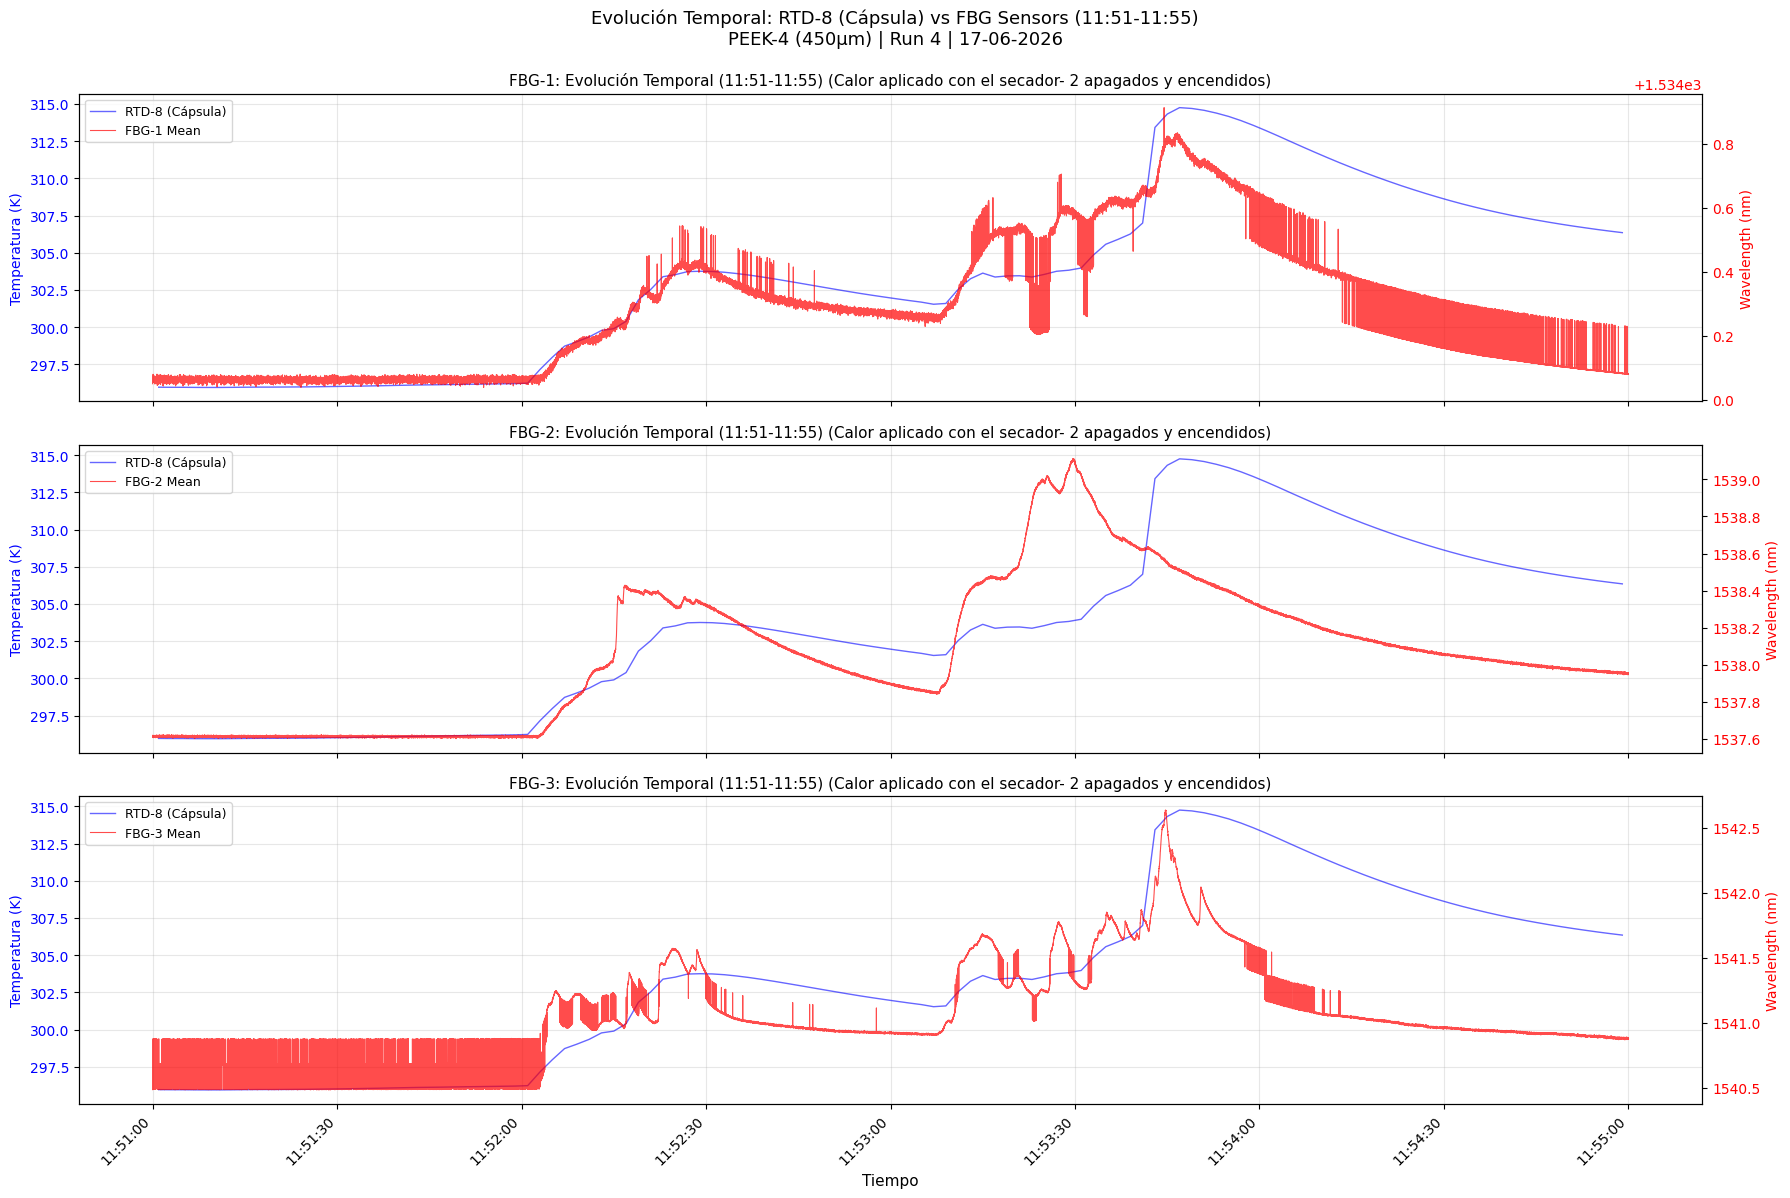


📊 Rango temporal mostrado: (11:51-11:55)
   Temperatura: 2026-06-17 11:51 - 11:54
   Wavelength (con +0h shift): 2026-06-17 11:51 - 11:54

💡 Este gráfico muestra el TIME_SHIFT de 0 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [15]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(11, 51))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(11, 55))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (Calor aplicado con el secador- 2 apagados y encendidos)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 4 | 17-06-2026', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

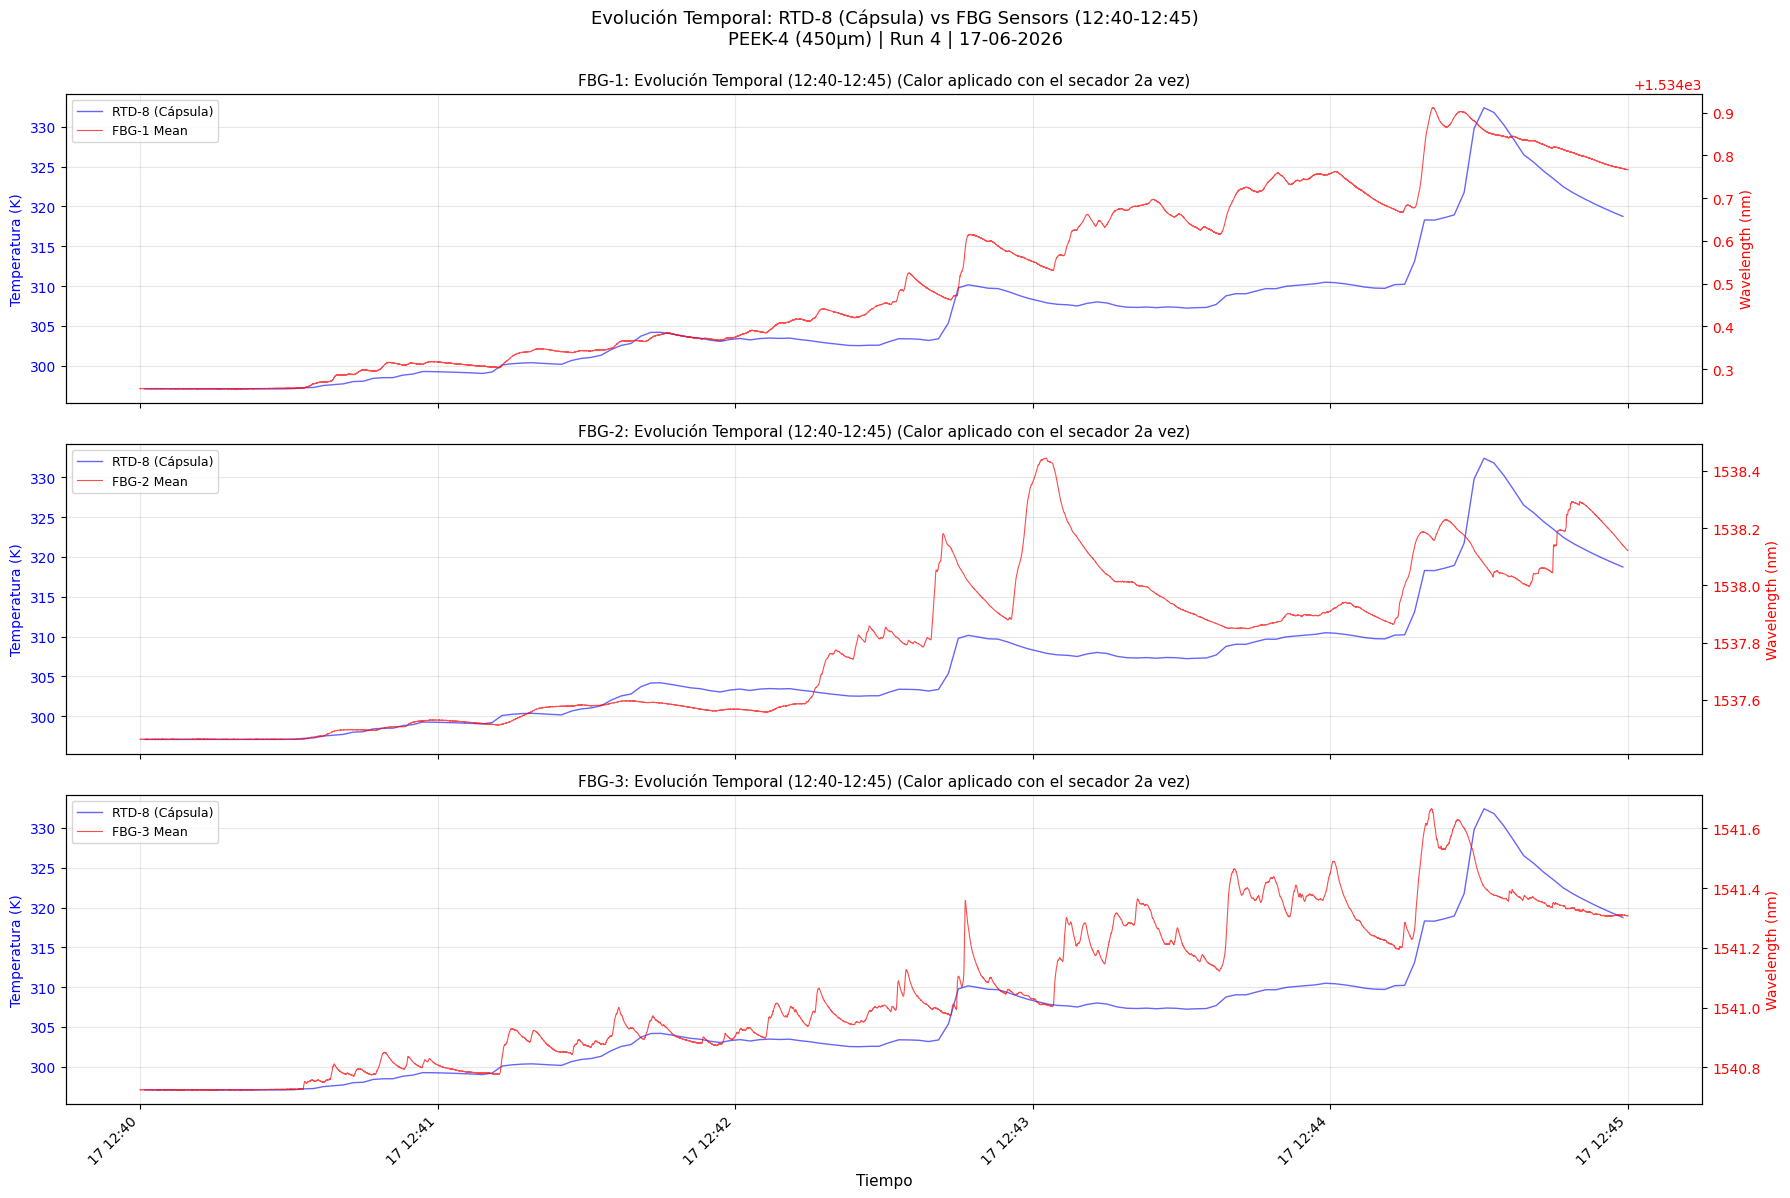


📊 Rango temporal mostrado: (12:40-12:45)
   Temperatura: 2026-06-17 12:40 - 12:44
   Wavelength (con +0h shift): 2026-06-17 12:40 - 12:44

💡 Este gráfico muestra el TIME_SHIFT de 0 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [16]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(12, 40))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(12, 45))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (Calor aplicado con el secador 2a vez)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 4 | 17-06-2026', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

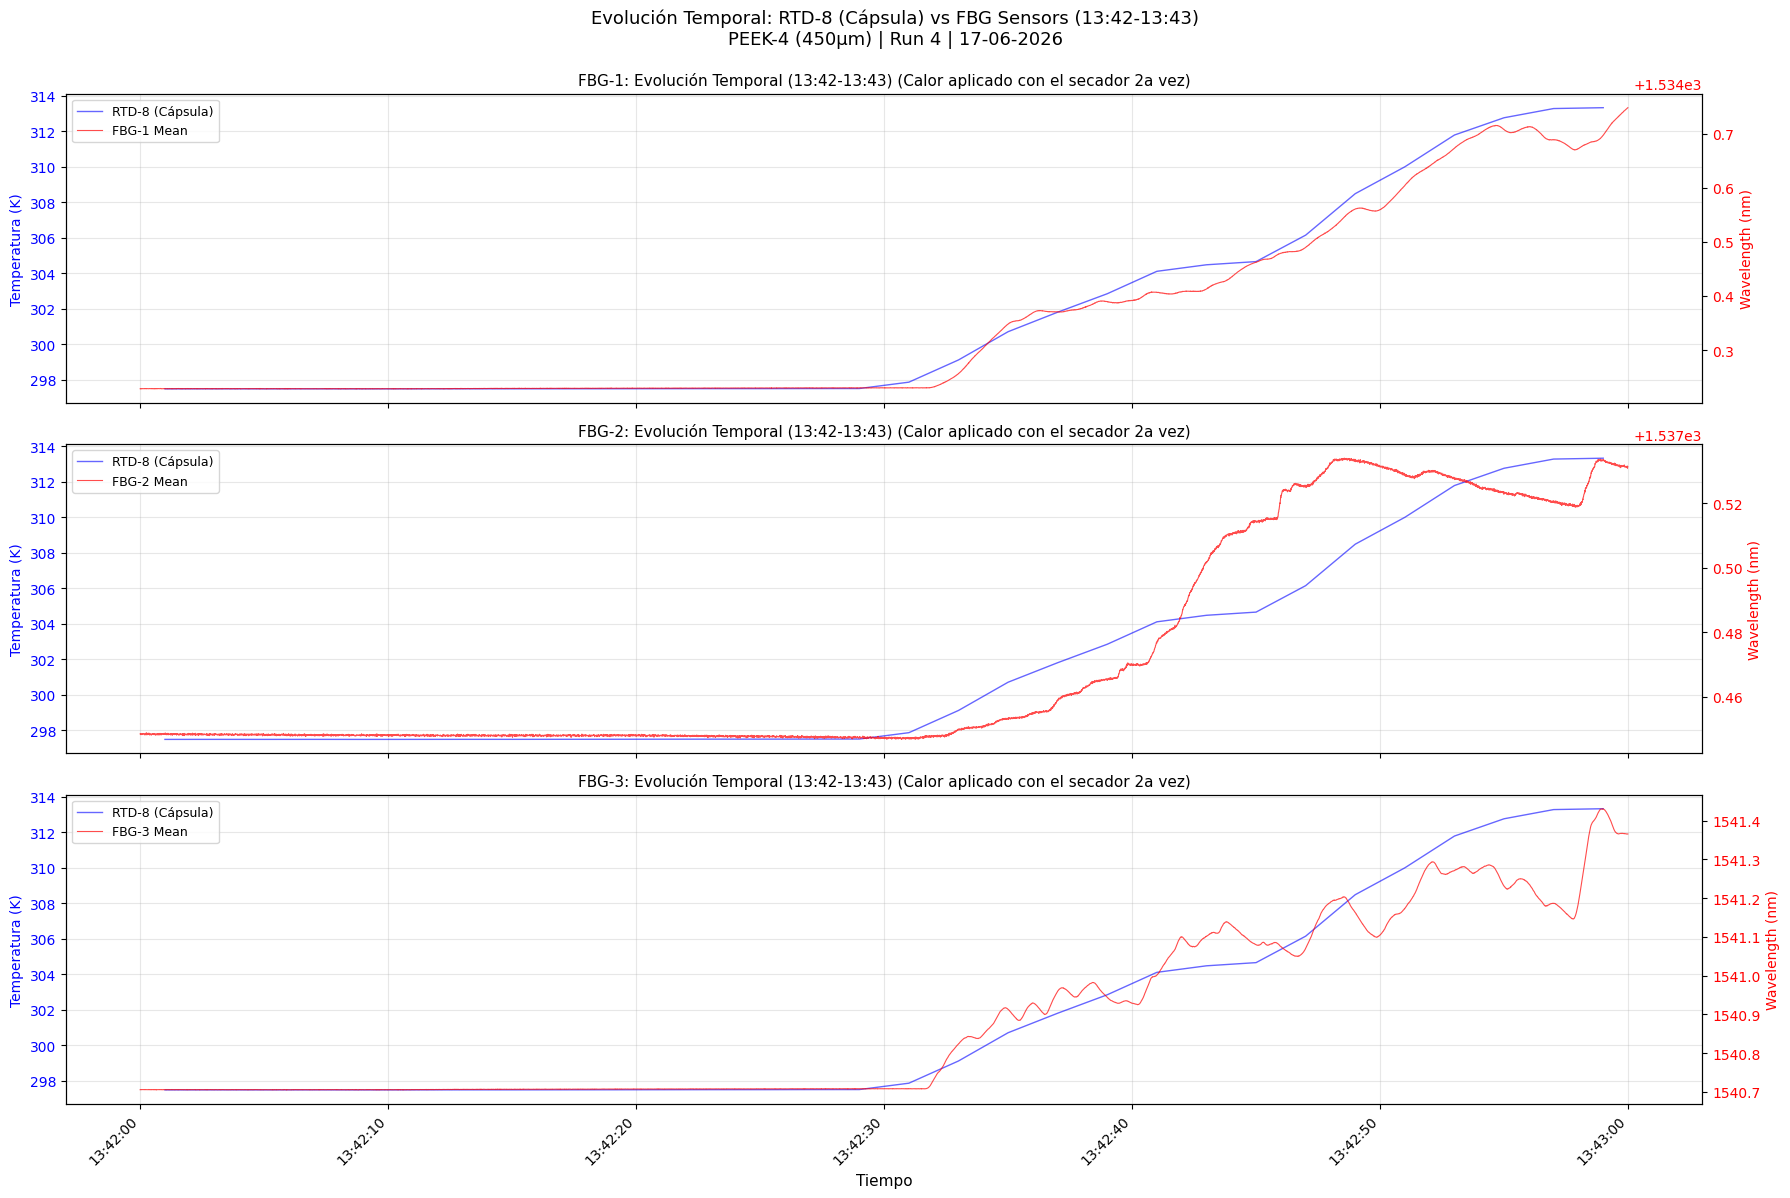


📊 Rango temporal mostrado: (13:42-13:43)
   Temperatura: 2026-06-17 13:42 - 13:42
   Wavelength (con +0h shift): 2026-06-17 13:42 - 13:42

💡 Este gráfico muestra el TIME_SHIFT de 0 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [17]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(13, 42))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(13, 43))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (Calor aplicado con el secador 2a vez)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 4 | 17-06-2026', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

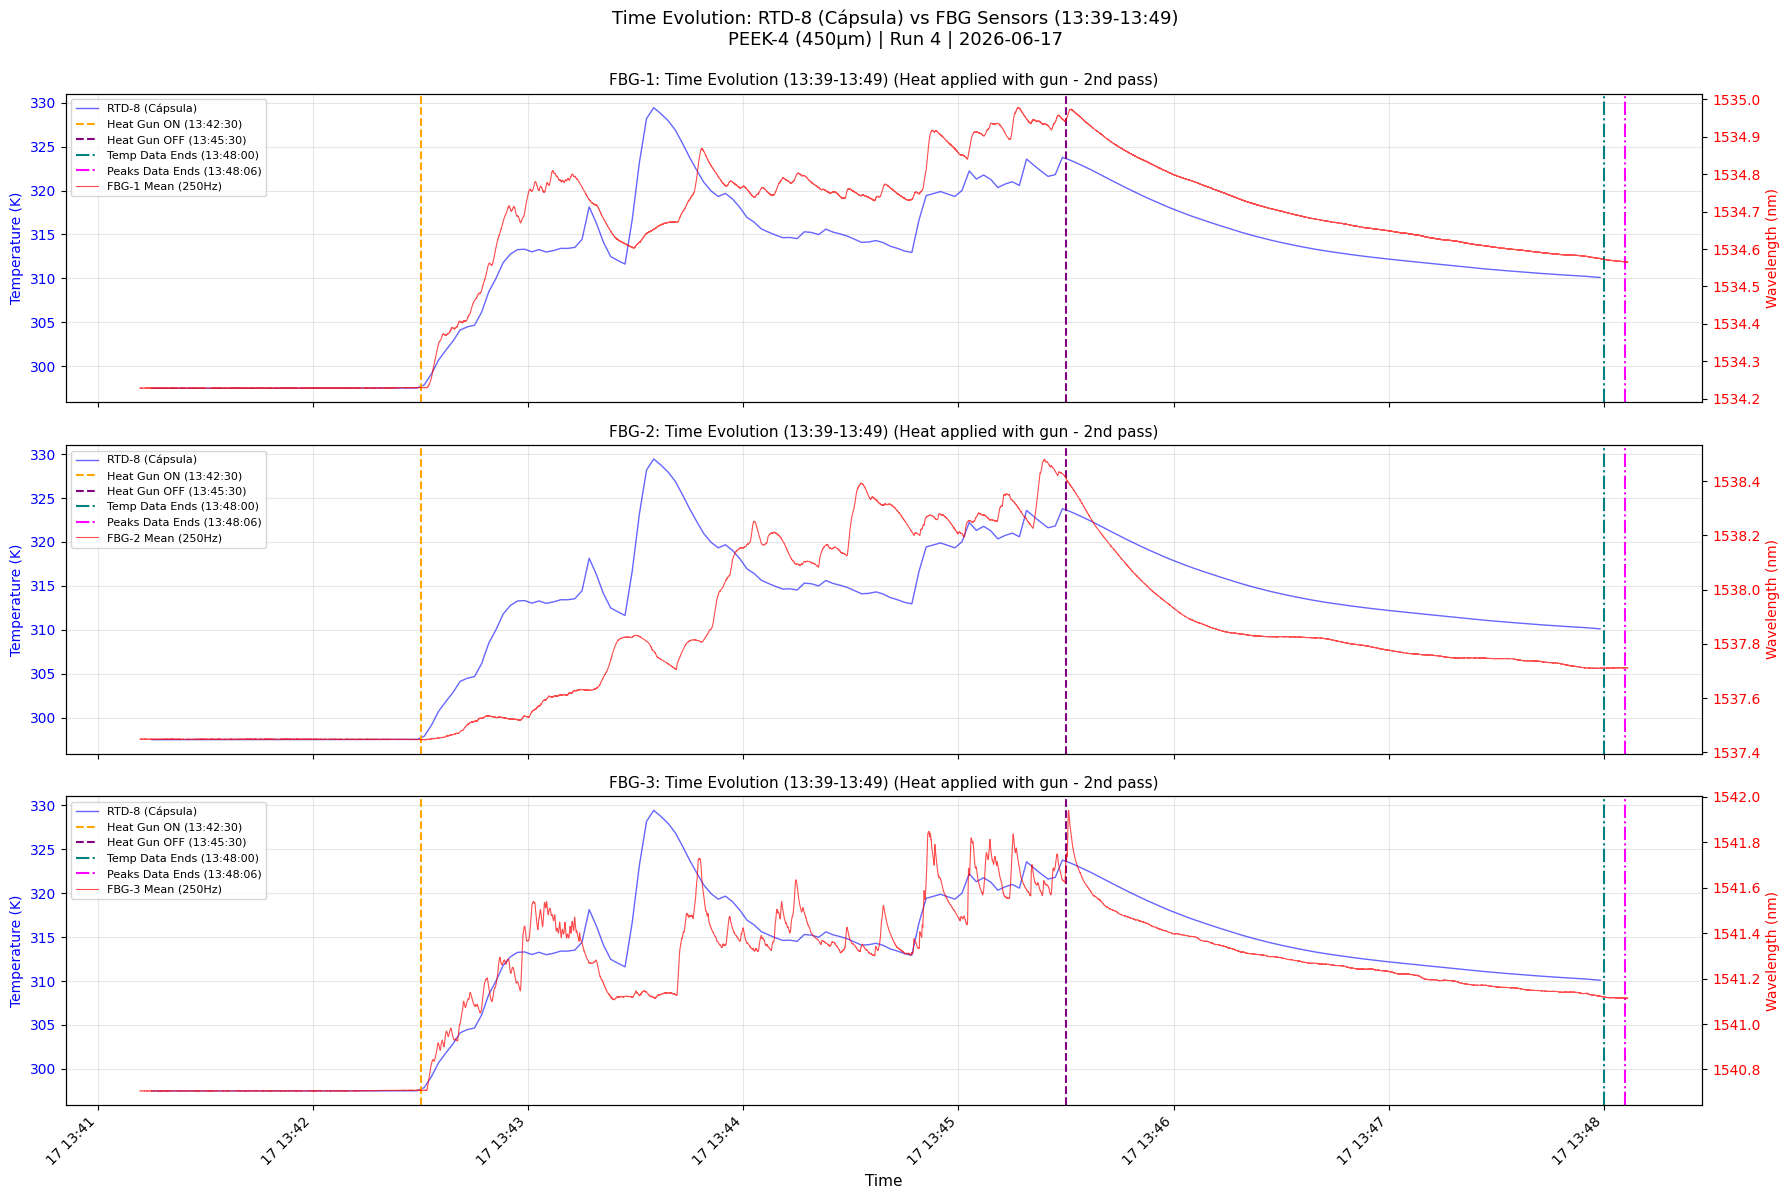


📊 Displayed time range: (13:39-13:49)
   Temperature: 2026-06-17 13:41:15 - 13:47:59
   Wavelength (with +0h shift): 2026-06-17 13:41:11 - 13:48:06

💡 This plot shows the TIME_SHIFT of 0 hours applied to the wavelength data
   to temporally align it with the temperature.

⚙️  To view the full range: change 'use_filtered_range_plot = False'


In [25]:
# ============================================================================
# CONFIGURATION: Filter by time range (optional)
# ============================================================================
# Option A: Show the ENTIRE available time range
use_filtered_range_plot = True  # Change to True to filter by a specific range

if use_filtered_range_plot:
    # Option B: Define a specific range for visualization
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(13, 39))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(13, 49))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Show full available range
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Full range)"
# ============================================================================

# Define temporal synchronization events
# Note: Heat gun ON adjusted to 13:42:30 to logically precede OFF at 13:45:30
event_heat_on = datetime.datetime.combine(fecha, datetime.time(13, 42, 30))
event_heat_off = datetime.datetime.combine(fecha, datetime.time(13, 45, 30))
event_temp_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 0))
event_peaks_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 6))

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filter temperature data based on the selected range
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extract complete RAW data
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # P Polarization
    wav_s_full = wav_raw[:, 1, sensor_idx]  # S Polarization
    
    # Filter positive values and by time range
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolate S to P times
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Mean (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperature
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperature (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Add vertical lines for synchronization events
    ax.axvline(x=event_heat_on, color='orange', linestyle='--', linewidth=1.5, label='Heat Gun ON (13:42:30)')
    ax.axvline(x=event_heat_off, color='purple', linestyle='--', linewidth=1.5, label='Heat Gun OFF (13:45:30)')
    ax.axvline(x=event_temp_end, color='teal', linestyle='-.', linewidth=1.5, label='Temp Data Ends (13:48:00)')
    ax.axvline(x=event_peaks_end, color='magenta', linestyle='-.', linewidth=1.5, label='Peaks Data Ends (13:48:06)')
    
    # Plot wavelength on secondary axis
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean (250Hz)')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # Move legend slightly outside or keep it tight to prevent overlap with lines
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    
    ax.set_title(f'FBG-{sensor_num}: Time Evolution {range_label} (Heat applied with gun - 2nd pass)', 
                 fontsize=11)

# Configure X-axis only on the last subplot
axes[-1].set_xlabel('Time', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Time Evolution: {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 4 | 2026-06-17', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Displayed time range: {range_label}")
if len(times_temp_plot) > 0:
    print(f"   Temperature: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_temp_plot[-1].strftime('%H:%M:%S')}")
if len(times_p_plot) > 0:
    print(f"   Wavelength (with +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_p_plot[-1].strftime('%H:%M:%S')}")

print(f"\n💡 This plot shows the TIME_SHIFT of {TIME_SHIFT.total_seconds()/3600:.0f} hours applied to the wavelength data")
print(f"   to temporally align it with the temperature.")
if use_filtered_range_plot:
    print(f"\n⚙️  To view the full range: change 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  To filter by a specific time range: change 'use_filtered_range_plot = True'")

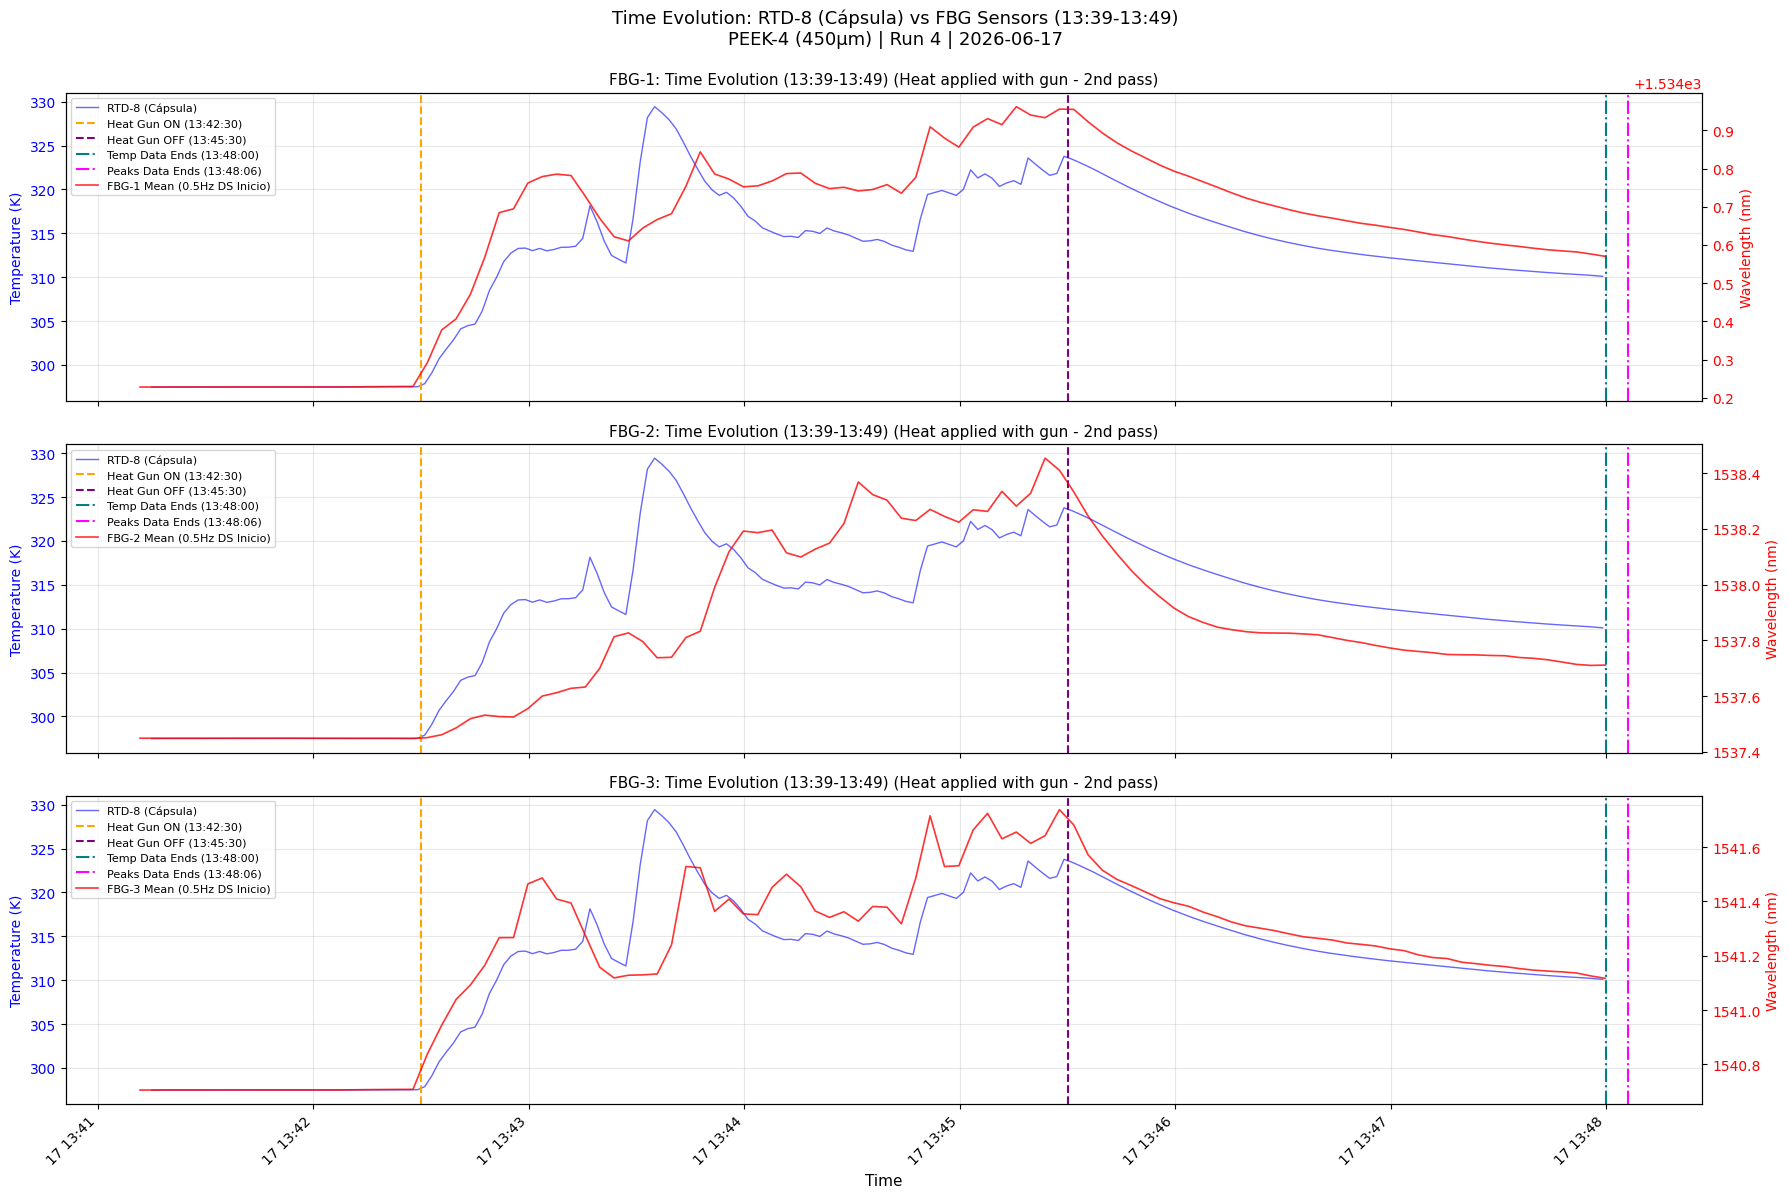

In [19]:
# ============================================================================
# CONFIGURATION: Filter by time range (optional)
# ============================================================================
# Option A: Show the ENTIRE available time range
use_filtered_range_plot = True  # Change to True to filter by a specific range

if use_filtered_range_plot:
    # Option B: Define a specific range for visualization
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(13, 39))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(13, 49))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Show full available range
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Full range)"
# ============================================================================

# Define temporal synchronization events
event_heat_on = datetime.datetime.combine(fecha, datetime.time(13, 42, 30))
event_heat_off = datetime.datetime.combine(fecha, datetime.time(13, 45, 30))
event_temp_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 0))
event_peaks_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 6))

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filter temperature data based on the selected range
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extract complete RAW data
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # P Polarization
    wav_s_full = wav_raw[:, 1, sensor_idx]  # S Polarization
    
    # Filter positive values and by time range
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolate S to P times
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Mean (P+S)/2 (Señal en crudo a 250Hz)
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    # ----------------------------------------------------------------------
    # DOWNSAMPLING MANUAL (Timestamp al inicio del bloque emulando a los RTDs)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_plot) // ds_factor
    
    if num_blocks > 0:
        # 1. Agrupamos los datos en bloques de 500 y calculamos la media
        wav_mean_plot_ds = np.mean(wav_mean_plot[:num_blocks*ds_factor].reshape(-1, ds_factor), axis=1)
        # 2. Tomamos el timestamp del INICIO de la ventana (índice 0).
        times_p_plot_ds = times_p_plot[0 : num_blocks*ds_factor : ds_factor]
    else:
        # Fallback de seguridad
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot
    # ----------------------------------------------------------------------
    
    ax = axes[idx]
    
    # Plot temperature
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperature (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Add vertical lines for synchronization events
    ax.axvline(x=event_heat_on, color='orange', linestyle='--', linewidth=1.5, label='Heat Gun ON (13:42:30)')
    ax.axvline(x=event_heat_off, color='purple', linestyle='--', linewidth=1.5, label='Heat Gun OFF (13:45:30)')
    ax.axvline(x=event_temp_end, color='teal', linestyle='-.', linewidth=1.5, label='Temp Data Ends (13:48:00)')
    ax.axvline(x=event_peaks_end, color='magenta', linestyle='-.', linewidth=1.5, label='Peaks Data Ends (13:48:06)')
    
    # Plot wavelength on secondary axis
    ax2 = ax.twinx()
    ax2.plot(times_p_plot_ds, wav_mean_plot_ds, 'r-', linewidth=1.2, alpha=0.8, label=f'FBG-{sensor_num} Mean (0.5Hz DS Inicio)')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    
    ax.set_title(f'FBG-{sensor_num}: Time Evolution {range_label} (Heat applied with gun - 2nd pass)', 
                 fontsize=11)

# Configure X-axis only on the last subplot
axes[-1].set_xlabel('Time', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Time Evolution: {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 4 | 2026-06-17', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

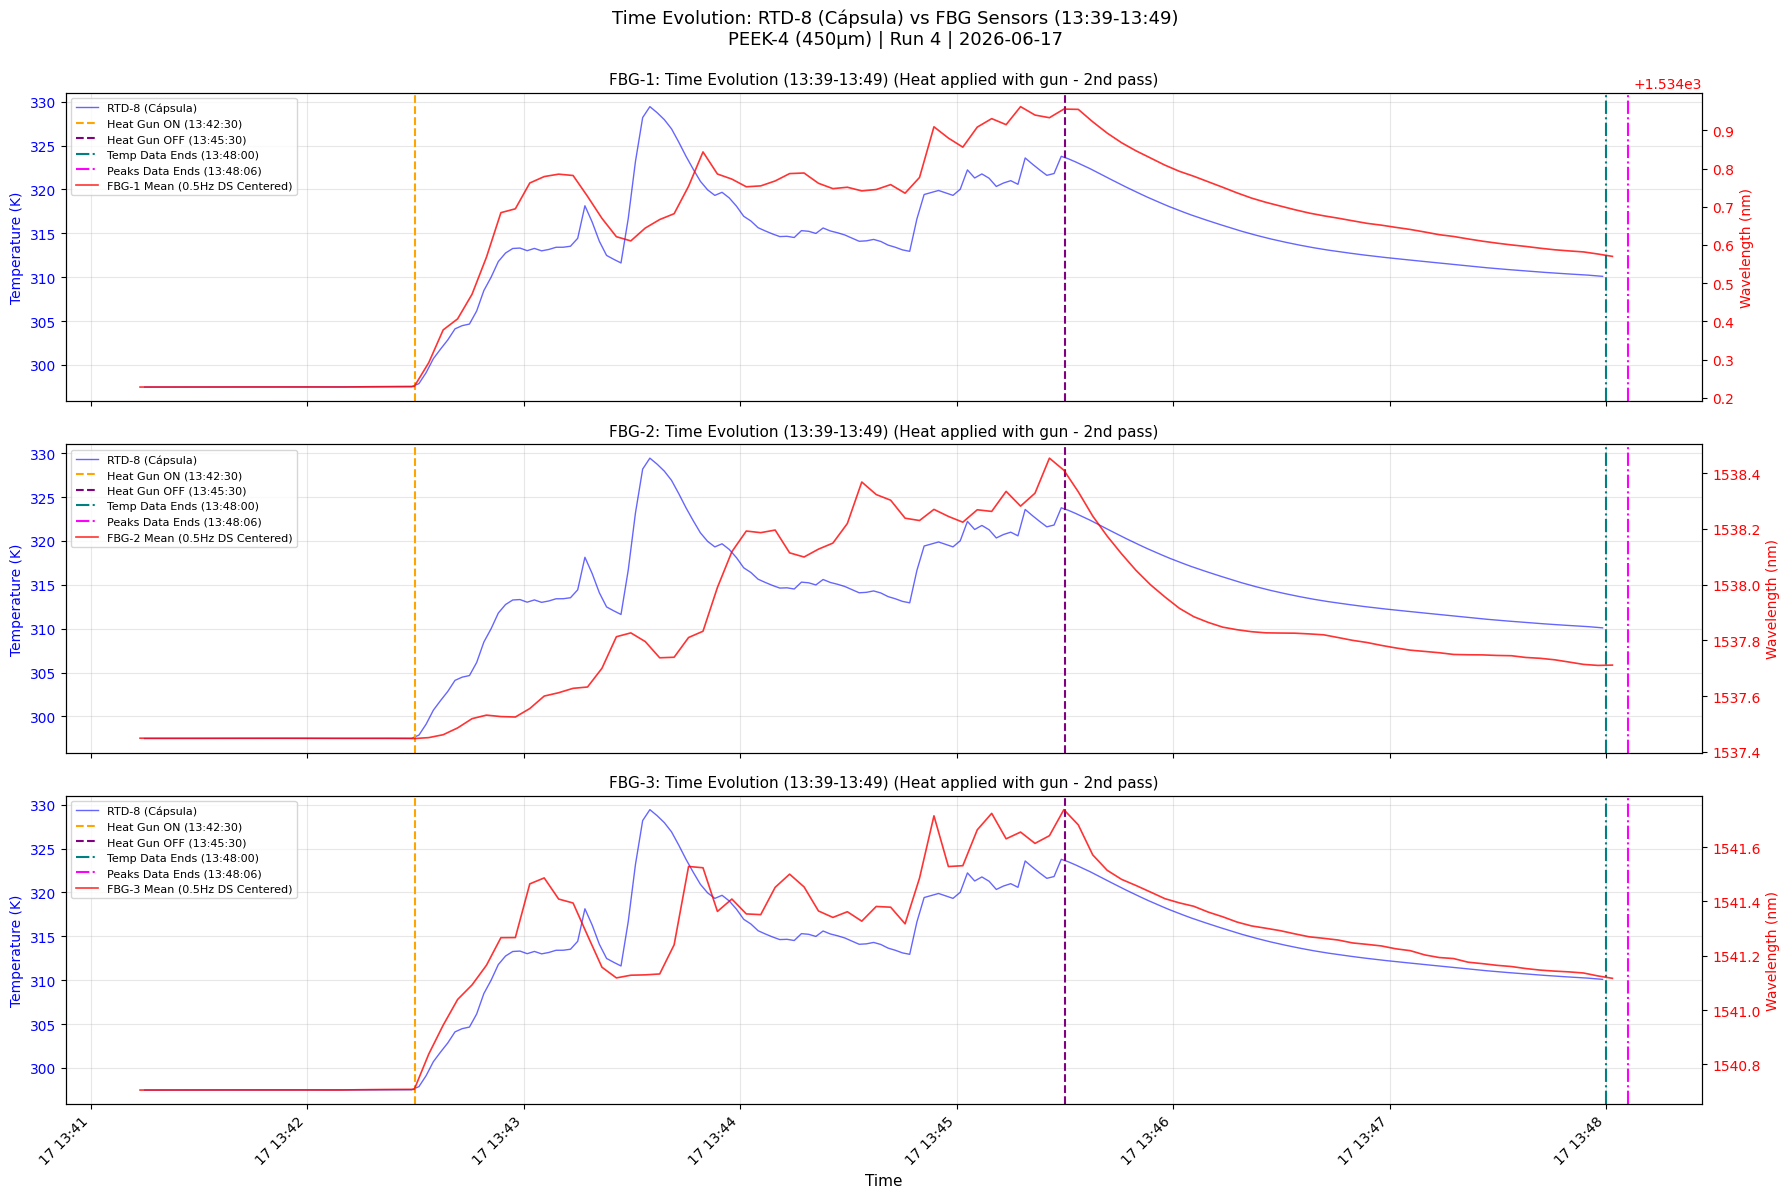

In [20]:
# ============================================================================
# CONFIGURATION: Filter by time range (optional)
# ============================================================================
# Option A: Show the ENTIRE available time range
use_filtered_range_plot = True  # Change to True to filter by a specific range

if use_filtered_range_plot:
    # Option B: Define a specific range for visualization
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(13, 39))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(13, 49))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Show full available range
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Full range)"
# ============================================================================

# Define temporal synchronization events
event_heat_on = datetime.datetime.combine(fecha, datetime.time(13, 42, 30))
event_heat_off = datetime.datetime.combine(fecha, datetime.time(13, 45, 30))
event_temp_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 0))
event_peaks_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 6))

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filter temperature data based on the selected range
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)
half_ds_factor = ds_factor // 2   # Índice central del bloque

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extract complete RAW data
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # P Polarization
    wav_s_full = wav_raw[:, 1, sensor_idx]  # S Polarization
    
    # Filter positive values and by time range
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolate S to P times
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Mean (P+S)/2 (Señal en crudo a 250Hz)
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    # ----------------------------------------------------------------------
    # DOWNSAMPLING MANUAL CENTRADO (Timestamp en el centro del bloque)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_plot) // ds_factor
    
    if num_blocks > 0:
        # 1. Agrupamos los datos en bloques de 500 y calculamos la media
        wav_mean_plot_ds = np.mean(wav_mean_plot[:num_blocks*ds_factor].reshape(-1, ds_factor), axis=1)
        # 2. Tomamos el timestamp del CENTRO de la ventana para una representación imparcial.
        times_p_plot_ds = times_p_plot[half_ds_factor : num_blocks*ds_factor : ds_factor]
    else:
        # Fallback de seguridad
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot
    # ----------------------------------------------------------------------
    
    ax = axes[idx]
    
    # Plot temperature
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperature (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Add vertical lines for synchronization events
    ax.axvline(x=event_heat_on, color='orange', linestyle='--', linewidth=1.5, label='Heat Gun ON (13:42:30)')
    ax.axvline(x=event_heat_off, color='purple', linestyle='--', linewidth=1.5, label='Heat Gun OFF (13:45:30)')
    ax.axvline(x=event_temp_end, color='teal', linestyle='-.', linewidth=1.5, label='Temp Data Ends (13:48:00)')
    ax.axvline(x=event_peaks_end, color='magenta', linestyle='-.', linewidth=1.5, label='Peaks Data Ends (13:48:06)')
    
    # Plot wavelength on secondary axis
    ax2 = ax.twinx()
    ax2.plot(times_p_plot_ds, wav_mean_plot_ds, 'r-', linewidth=1.2, alpha=0.8, label=f'FBG-{sensor_num} Mean (0.5Hz DS Centered)')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    
    ax.set_title(f'FBG-{sensor_num}: Time Evolution {range_label} (Heat applied with gun - 2nd pass)', 
                 fontsize=11)

# Configure X-axis only on the last subplot
axes[-1].set_xlabel('Time', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Time Evolution: {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 4 | 2026-06-17', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

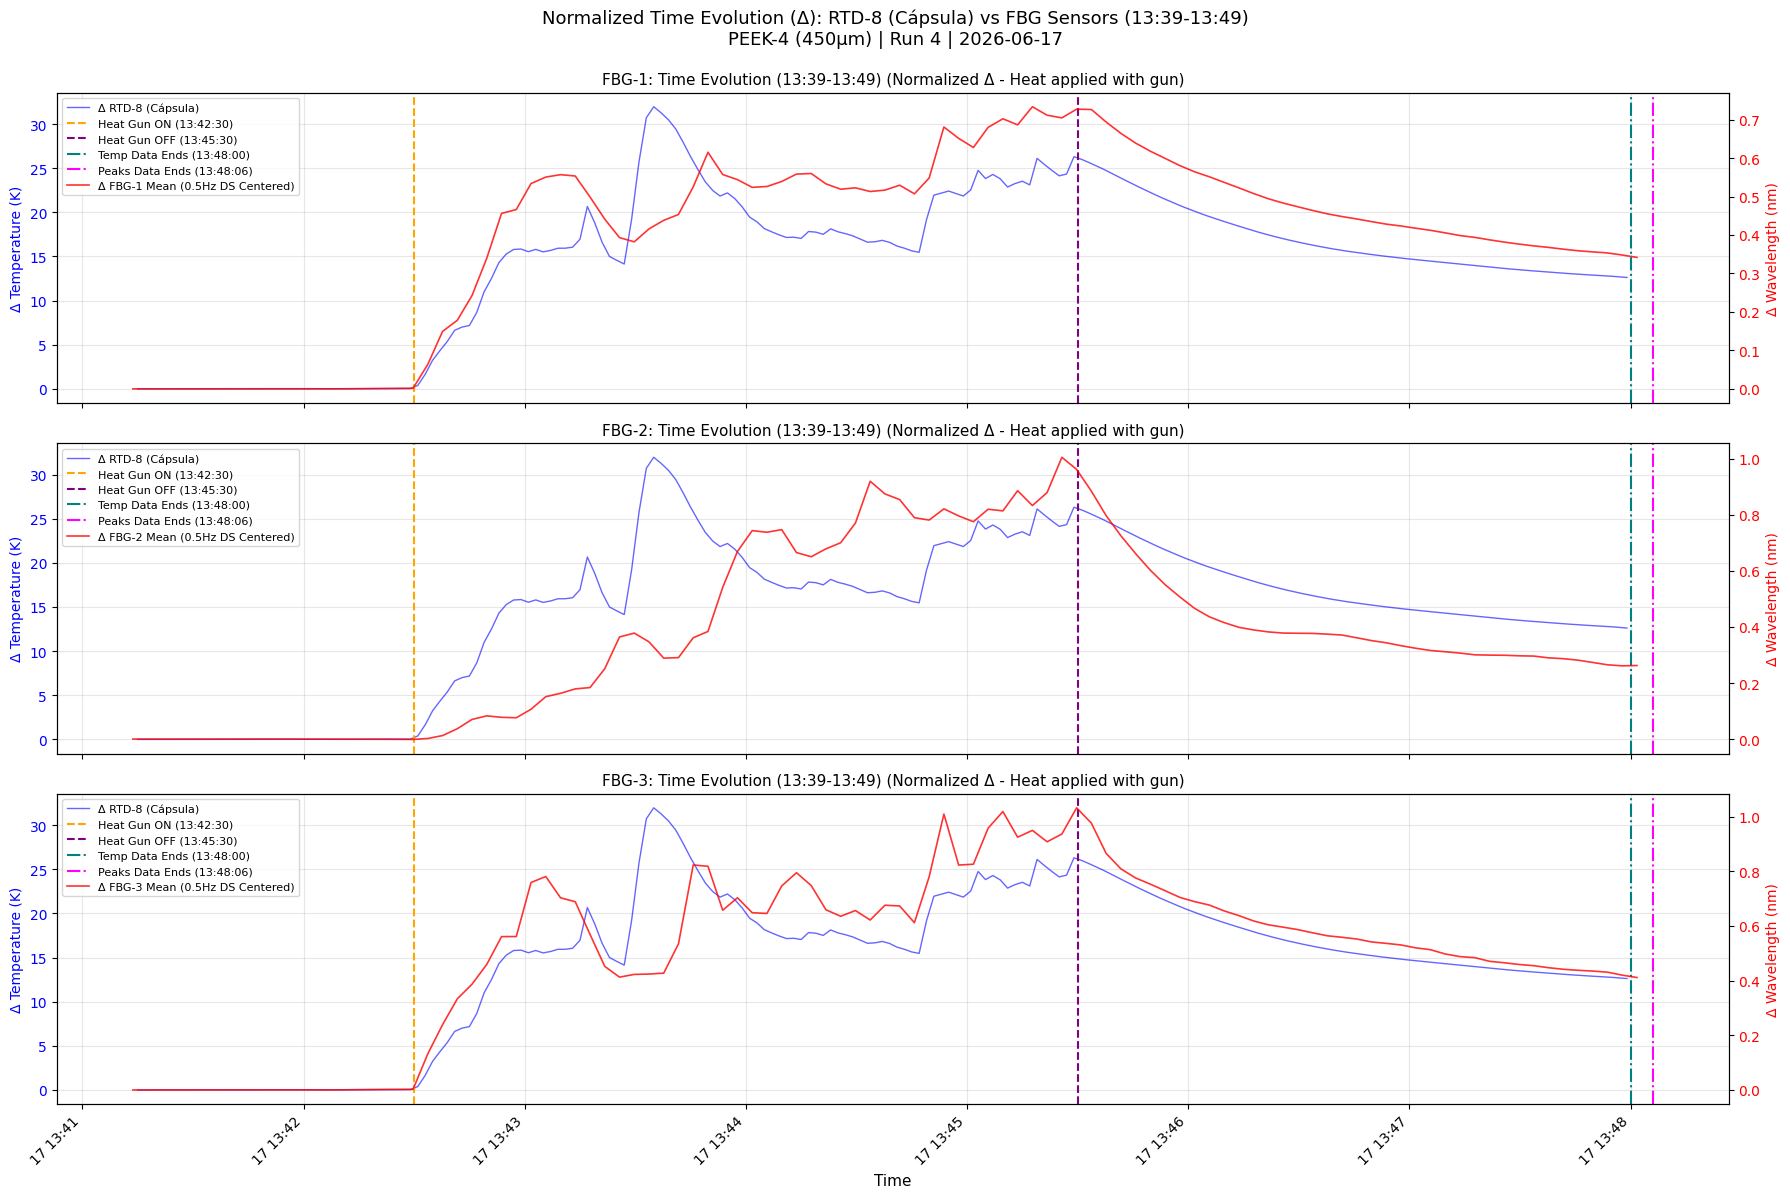

In [21]:
# ============================================================================
# CONFIGURATION: Filter by time range (optional)
# ============================================================================
# Option A: Show the ENTIRE available time range
use_filtered_range_plot = True  # Change to True to filter by a specific range

if use_filtered_range_plot:
    # Option B: Define a specific range for visualization
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(13, 39))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(13, 49))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Show full available range
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Full range)"
# ============================================================================

# Define temporal synchronization events
event_heat_on = datetime.datetime.combine(fecha, datetime.time(13, 42, 30))
event_heat_off = datetime.datetime.combine(fecha, datetime.time(13, 45, 30))
event_temp_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 0))
event_peaks_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 6))

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filter temperature data based on the selected range
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# NORMALIZACIÓN RTD: Calcular Delta T (Restar el valor inicial)
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp = temp_plot - temp_baseline

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)
half_ds_factor = ds_factor // 2   # Índice central del bloque

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extract complete RAW data
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # P Polarization
    wav_s_full = wav_raw[:, 1, sensor_idx]  # S Polarization
    
    # Filter positive values and by time range
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolate S to P times
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Mean (P+S)/2 (Señal en crudo a 250Hz)
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    # ----------------------------------------------------------------------
    # DOWNSAMPLING MANUAL CENTRADO (Timestamp en el centro del bloque)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_plot) // ds_factor
    
    if num_blocks > 0:
        # 1. Agrupamos los datos en bloques de 500 y calculamos la media
        wav_mean_plot_ds = np.mean(wav_mean_plot[:num_blocks*ds_factor].reshape(-1, ds_factor), axis=1)
        # 2. Tomamos el timestamp del CENTRO de la ventana para una representación imparcial.
        times_p_plot_ds = times_p_plot[half_ds_factor : num_blocks*ds_factor : ds_factor]
    else:
        # Fallback de seguridad
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot
    # ----------------------------------------------------------------------
    
    # NORMALIZACIÓN FBG: Calcular Delta Wavelength (Restar el valor inicial)
    wav_baseline = wav_mean_plot_ds[0] if len(wav_mean_plot_ds) > 0 else 0
    delta_wav = wav_mean_plot_ds - wav_baseline
    
    ax = axes[idx]
    
    # Plot temperature (Delta)
    ax.plot(times_temp_plot, delta_temp, 'b-', linewidth=1.0, alpha=0.6, label=f'Δ {rtd_ref_name}')
    ax.set_ylabel('Δ Temperature (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Add vertical lines for synchronization events
    ax.axvline(x=event_heat_on, color='orange', linestyle='--', linewidth=1.5, label='Heat Gun ON (13:42:30)')
    ax.axvline(x=event_heat_off, color='purple', linestyle='--', linewidth=1.5, label='Heat Gun OFF (13:45:30)')
    ax.axvline(x=event_temp_end, color='teal', linestyle='-.', linewidth=1.5, label='Temp Data Ends (13:48:00)')
    ax.axvline(x=event_peaks_end, color='magenta', linestyle='-.', linewidth=1.5, label='Peaks Data Ends (13:48:06)')
    
    # Plot wavelength on secondary axis (Delta)
    ax2 = ax.twinx()
    ax2.plot(times_p_plot_ds, delta_wav, 'r-', linewidth=1.2, alpha=0.8, label=f'Δ FBG-{sensor_num} Mean (0.5Hz DS Centered)')
    ax2.set_ylabel('Δ Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    
    ax.set_title(f'FBG-{sensor_num}: Time Evolution {range_label} (Normalized Δ - Heat applied with gun)', 
                 fontsize=11)

# Configure X-axis only on the last subplot
axes[-1].set_xlabel('Time', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Normalized Time Evolution (Δ): {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 4 | 2026-06-17', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

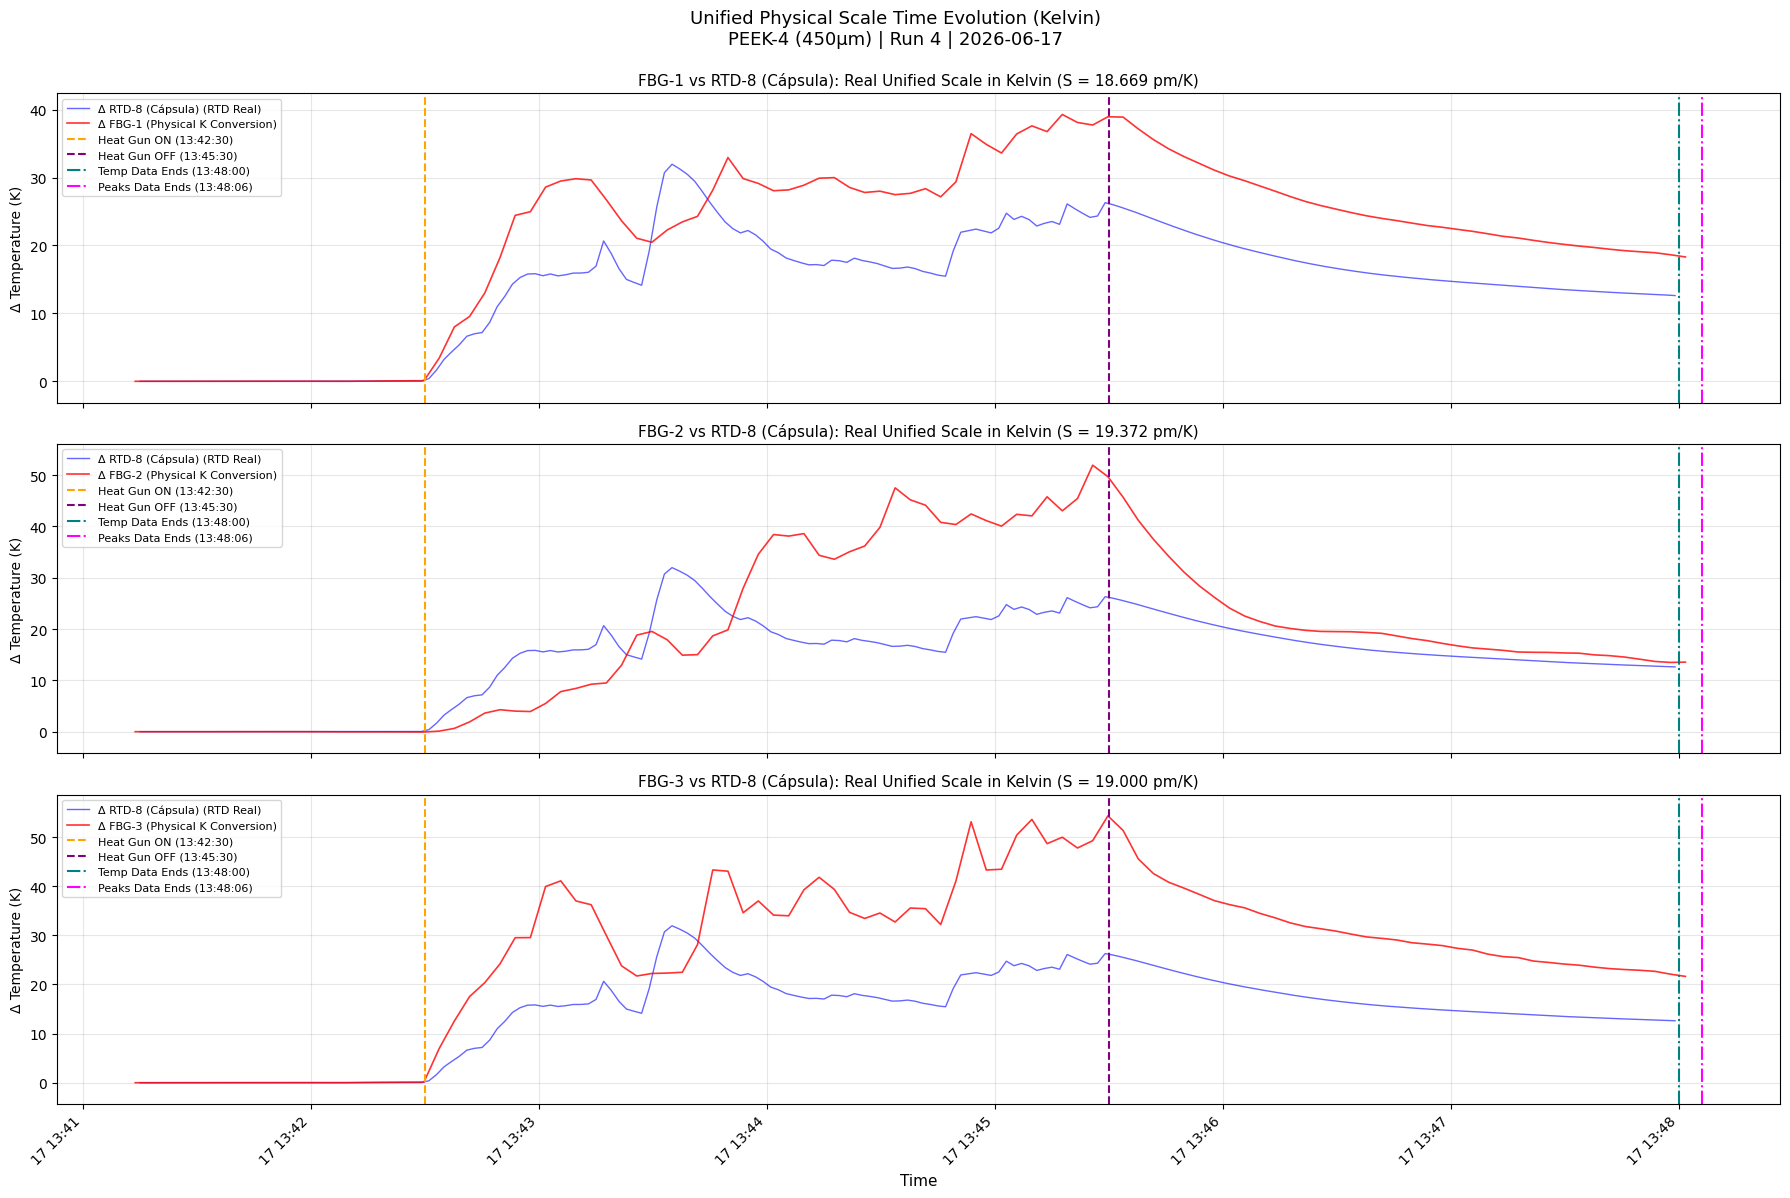

In [22]:
import datetime
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# CONFIGURATION: Filter by time range (optional)
# ============================================================================
use_filtered_range_plot = True  # Change to True to filter by a specific range

if use_filtered_range_plot:
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(13, 39))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(13, 49))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Full range)"

# ============================================================================
# PARÁMETROS FÍSICOS REALES (Calibración)
# Modifica el valor del Sensor 3 si tienes su dato exacto en la tabla
# ============================================================================
fbg_sensitivities_nm_K = {
    1: 18.669 * 1e-3,  # 0.018669 nm/K
    2: 19.372 * 1e-3,  # 0.019372 nm/K
    3: 19.000 * 1e-3,  # 0.019000 nm/K (¡Ajustar al valor real de tu tabla!)
}

# Define temporal synchronization events
event_heat_on = datetime.datetime.combine(fecha, datetime.time(13, 42, 30))
event_heat_off = datetime.datetime.combine(fecha, datetime.time(13, 45, 30))
event_temp_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 0))
event_peaks_end = datetime.datetime.combine(fecha, datetime.time(13, 48, 6))

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filter temperature data based on the selected range
temp_raw_valid_mask = (
    (temp_raw[:, rtd_ref_idx] > 0)
    & (times_temp >= t_plot_inicio)
    & (times_temp <= t_plot_fin)
)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# NORMALIZACIÓN RTD: Calcular Delta T (Restar el valor inicial)
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp_K = temp_plot - temp_baseline

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)
half_ds_factor = ds_factor // 2  # Índice central del bloque

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_sensitivity_nm_K = fbg_sensitivities_nm_K[sensor_num]

    # Extract complete RAW data
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # P Polarization
    wav_s_full = wav_raw[:, 1, sensor_idx]  # S Polarization

    # Filter positive values and by time range
    mask_p = (
        (wav_p_full > 0)
        & (times_peak >= t_plot_inicio)
        & (times_peak <= t_plot_fin)
    )
    mask_s = (
        (wav_s_full > 0)
        & (times_peak >= t_plot_inicio)
        & (times_peak <= t_plot_fin)
    )

    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]

    # Interpolate S to P times
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)

    # Mean (P+S)/2 (Señal en crudo a 250Hz)
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0

    # ----------------------------------------------------------------------
    # DOWNSAMPLING MANUAL CENTRADO (Timestamp en el centro del bloque)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_plot) // ds_factor

    if num_blocks > 0:
        # 1. Agrupamos los datos en bloques de 500 y calculamos la media
        wav_mean_plot_ds = np.mean(
            wav_mean_plot[: num_blocks * ds_factor].reshape(-1, ds_factor),
            axis=1,
        )
        # 2. Tomamos el timestamp del CENTRO de la ventana para una representación imparcial.
        times_p_plot_ds = times_p_plot[
            half_ds_factor : num_blocks * ds_factor : ds_factor
        ]
    else:
        # Fallback de seguridad
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot
    # ----------------------------------------------------------------------

    # NORMALIZACIÓN FBG: Calcular Delta Wavelength (Restar el valor inicial)
    wav_baseline = wav_mean_plot_ds[0] if len(wav_mean_plot_ds) > 0 else 0
    delta_wav_nm = wav_mean_plot_ds - wav_baseline

    # ----------------------------------------------------------------------
    # CONVERSIÓN FÍSICA ESTRICTA A KELVIN EQUIVALENTES (Mismo estilo)
    # ----------------------------------------------------------------------
    fbg_temp_equivalent_K = delta_wav_nm / fbg_sensitivity_nm_K
    # ----------------------------------------------------------------------

    ax = axes[idx]

    # Plot ambas señales juntas en el MISMO EJE Y (Unidades: Kelvin)
    ax.plot(
        times_temp_plot,
        delta_temp_K,
        "b-",
        linewidth=1.0,
        alpha=0.6,
        label=f"Δ {rtd_ref_name} (RTD Real)",
    )
    ax.plot(
        times_p_plot_ds,
        fbg_temp_equivalent_K,
        "r-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Δ FBG-{sensor_num} (Physical K Conversion)",
    )

    ax.set_ylabel("Δ Temperature (K)", fontsize=10)
    ax.grid(True, alpha=0.3)

    # Add vertical lines for synchronization events
    ax.axvline(
        x=event_heat_on,
        color="orange",
        linestyle="--",
        linewidth=1.5,
        label="Heat Gun ON (13:42:30)",
    )
    ax.axvline(
        x=event_heat_off,
        color="purple",
        linestyle="--",
        linewidth=1.5,
        label="Heat Gun OFF (13:45:30)",
    )
    ax.axvline(
        x=event_temp_end,
        color="teal",
        linestyle="-.",
        linewidth=1.5,
        label="Temp Data Ends (13:48:00)",
    )
    ax.axvline(
        x=event_peaks_end,
        color="magenta",
        linestyle="-.",
        linewidth=1.5,
        label="Peaks Data Ends (13:48:06)",
    )

    # LÍMITES COMPARTIDOS DINÁMICOS: Evita que se recorten los picos de calor
    all_values = np.concatenate([delta_temp_K, fbg_temp_equivalent_K])
    y_min, y_max = np.min(all_values), np.max(all_values)
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.08 * y_range, y_max + 0.08 * y_range)

    # Legend
    ax.legend(loc="upper left", fontsize=8)

    ax.set_title(
        f"FBG-{sensor_num} vs {rtd_ref_name}: Real Unified Scale in Kelvin (S = {fbg_sensitivity_nm_K*1e3:.3f} pm/K)",
        fontsize=11,
    )

# Configure X-axis only on the last subplot
axes[-1].set_xlabel("Time", fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

plt.suptitle(
    f"Unified Physical Scale Time Evolution (Kelvin)\nPEEK-4 (450µm) | Run 4 | 2026-06-17",
    fontsize=13,
    y=0.995,
)
plt.tight_layout()
plt.show()

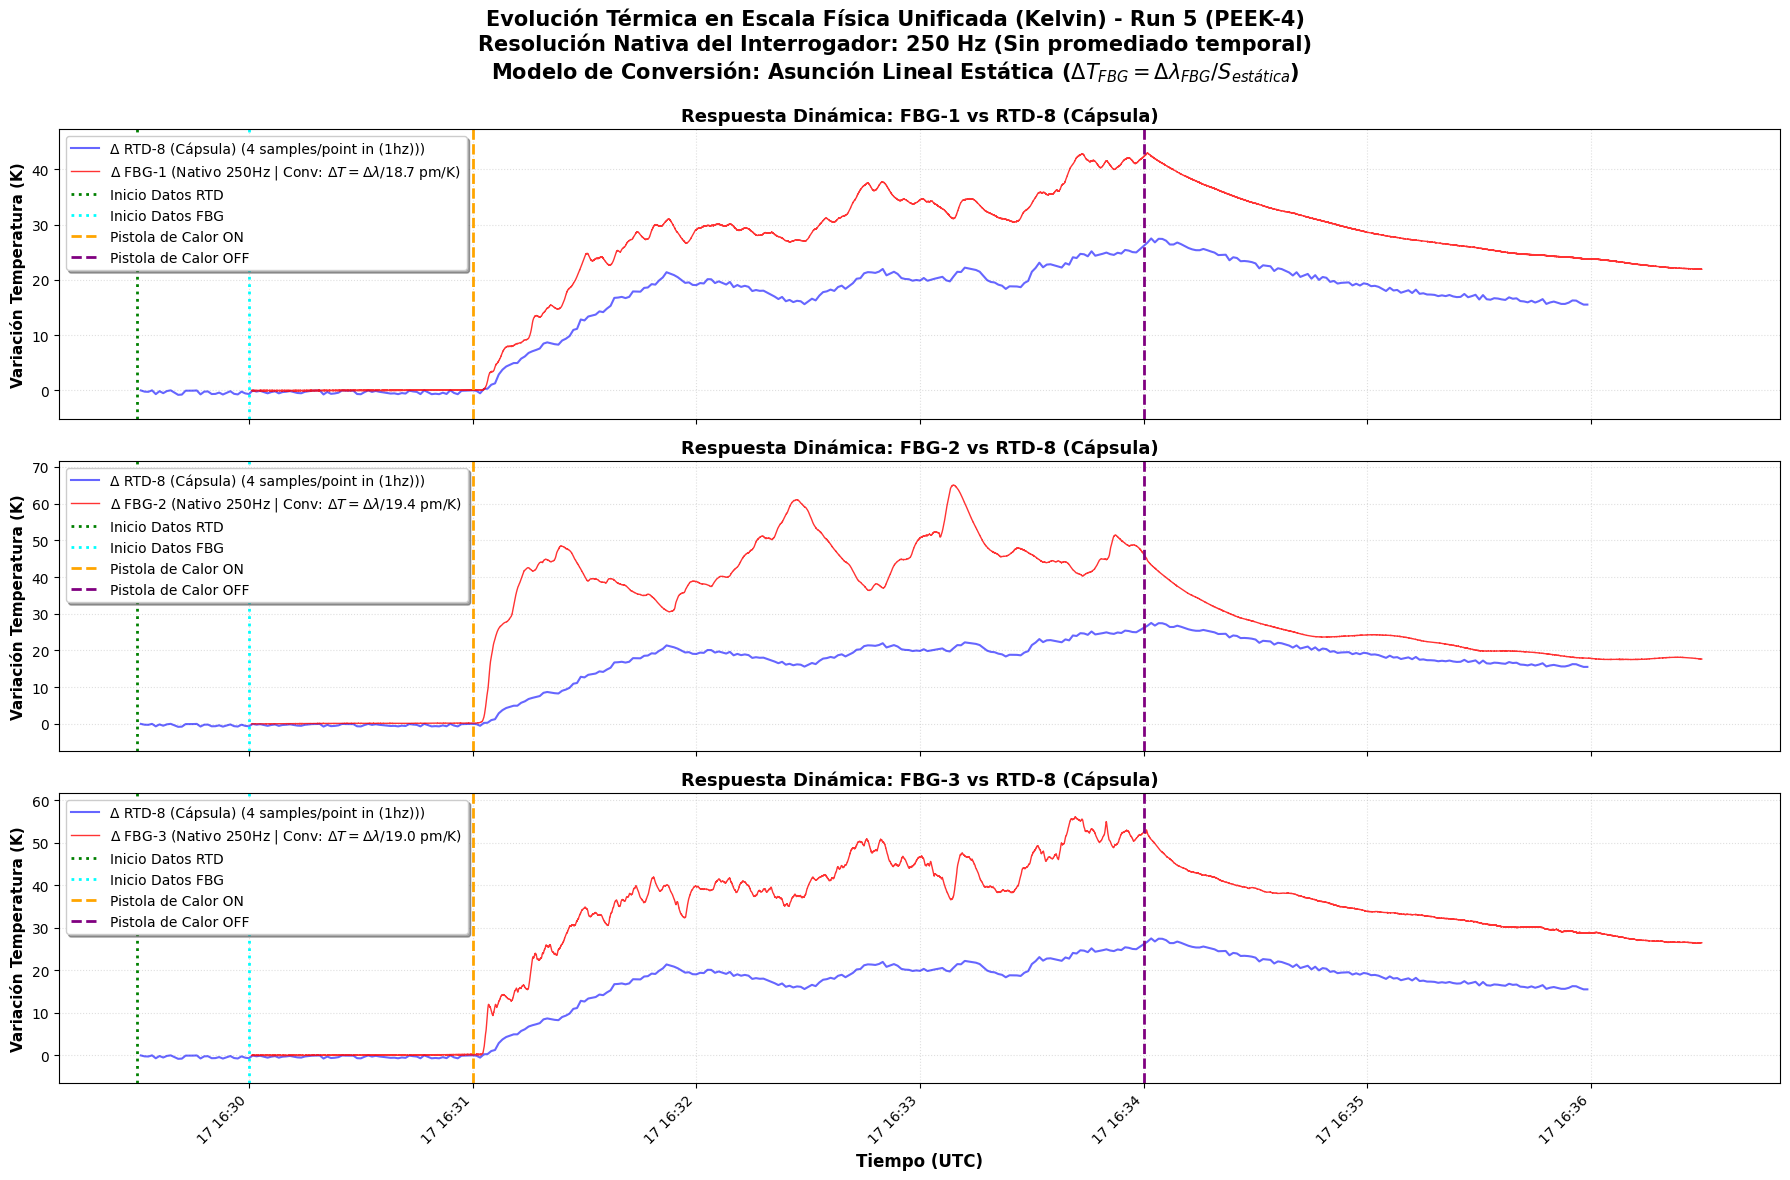

In [32]:
import datetime
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# PASO 1: CONFIGURACIÓN Y EVENTOS DEL EXPERIMENTO
# ============================================================================
use_filtered_range_plot = True  

# Asumimos que la variable 'fecha' ya existe (ej: fecha = datetime.date(2026, 6, 17))
if use_filtered_range_plot:
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(16, 28))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(17, 0))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango Completo)"

# Eventos físicos para pintar líneas verticales de referencia
eventos = [
    (datetime.datetime.combine(fecha, datetime.time(16, 29, 30)), "green", ":", "Inicio Datos RTD"),
    (datetime.datetime.combine(fecha, datetime.time(16, 30, 0)), "cyan", ":", "Inicio Datos FBG"),
    (datetime.datetime.combine(fecha, datetime.time(16, 31, 0)), "orange", "--", "Pistola de Calor ON"),
    (datetime.datetime.combine(fecha, datetime.time(16, 34, 0)), "purple", "--", "Pistola de Calor OFF"),
]

# Sensibilidades estáticas (convertidas a nm/K para que cuadren con los datos crudos en nm)
fbg_sensitivities_nm_K = {
    1: 18.669 * 1e-3,  # FBG-1
    2: 19.372 * 1e-3,  # FBG-2
    3: 19.000 * 1e-3,  # FBG-3
}

# ============================================================================
# PASO 2: INICIALIZACIÓN DEL GRÁFICO
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# --- A. PROCESADO DEL RTD (Referencia) ---
# Extraemos los datos del RTD solo en el rango de tiempo deseado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & (times_temp >= t_plot_inicio) & (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# Fijamos el 'cero' restando el primer valor. Así graficamos incrementos (ΔT) y no valores absolutos.
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp_K = temp_plot - temp_baseline

# --- B. PROCESADO DE LAS FIBRAS (A 250 Hz NATIVOS) ---
for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_sensitivity_nm_K = fbg_sensitivities_nm_K[sensor_num]
    sensor_idx = sensor_num - 1
    
    # 1. Extracción de polarizaciones (P y S) en nanómetros
    wav_p_full = wav_raw[:, 0, sensor_idx]
    wav_s_full = wav_raw[:, 1, sensor_idx]

    # Filtramos por el rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)

    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]

    # 2. ALINEACIÓN DE POLARIZACIONES (NO ES DOWNSAMPLING)
    # Como el láser escanea la polarización P y luego la S, sus timestamps están desfasados microsegundos.
    # Interpolamos los valores de S para que coincidan exactamente con los tiempos de P.
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)

    # Ahora que P y S coinciden en el tiempo, calculamos la longitud de onda central media pura (a 250 Hz)
    wav_mean_raw = (wav_p_plot_valid + wav_s_interp_plot) / 2.0

    # 3. CÁLCULO DEL INCREMENTO (Δλ)
    # Restamos el valor inicial para que empiece en cero (igual que hicimos con el RTD)
    wav_baseline = wav_mean_raw[0] if len(wav_mean_raw) > 0 else 0
    delta_wav_nm = wav_mean_raw - wav_baseline

    # 4. CONVERSIÓN FÍSICA A TEMPERATURA (Eje unificado)
    # Aplicamos la ley: ΔT = Δλ / Sensibilidad
    fbg_temp_equivalent_K = delta_wav_nm / fbg_sensitivity_nm_K

    # --- C. DIBUJADO DEL PANEL DEL SENSOR ---
    ax = axes[idx]

    # Línea del RTD (Azul)
    ax.plot(
        times_temp_plot, delta_temp_K, "b-", linewidth=1.5, alpha=0.6,
        label=f"Δ {rtd_ref_name} (4 samples/point in (1hz)))"
    )
    
    # Línea del FBG (Rojo) - Se indica explícitamente que son datos crudos a 250Hz y la fórmula
    sens_pm_K = fbg_sensitivity_nm_K * 1000 # Convertir a pm/K para la leyenda
    ax.plot(
        times_p_plot, fbg_temp_equivalent_K, "r-", linewidth=1.0, alpha=0.8,
        label=rf"Δ FBG-{sensor_num} (Nativo 250Hz | Conv: $\Delta T = \Delta\lambda / {sens_pm_K:.1f}$ pm/K)"
    )

    ax.set_ylabel("Variación Temperatura (K)", fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.4, linestyle=':')

    # Dibujar los eventos
    for ev_time, ev_col, ev_style, ev_lab in eventos:
        if t_plot_inicio <= ev_time <= t_plot_fin:
            ax.axvline(x=ev_time, color=ev_col, linestyle=ev_style, linewidth=2, label=ev_lab)

    # Ajuste dinámico de los límites Y para que ambas curvas quepan perfectamente sin cortarse
    if len(delta_temp_K) > 0 or len(fbg_temp_equivalent_K) > 0:
        all_values = np.concatenate([delta_temp_K, fbg_temp_equivalent_K])
        y_min, y_max = np.min(all_values), np.max(all_values)
        y_range = y_max - y_min if (y_max - y_min) > 0 else 1.0
        ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)

    ax.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)
    ax.set_title(f"Respuesta Dinámica: FBG-{sensor_num} vs {rtd_ref_name}", fontsize=13, fontweight='bold')

# Configuración del eje X global
axes[-1].set_xlabel("Tiempo (UTC)", fontsize=12, fontweight='bold')
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

# Título principal hiper-detallado
plt.suptitle(
    "Evolución Térmica en Escala Física Unificada (Kelvin) - Run 5 (PEEK-4)\n"
    "Resolución Nativa del Interrogador: 250 Hz (Sin promediado temporal)\n"
    r"Modelo de Conversión: Asunción Lineal Estática ($\Delta T_{FBG} = \Delta\lambda_{FBG} / S_{estática}$)",
    fontsize=15,
    fontweight='bold',
    y=0.98,
)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

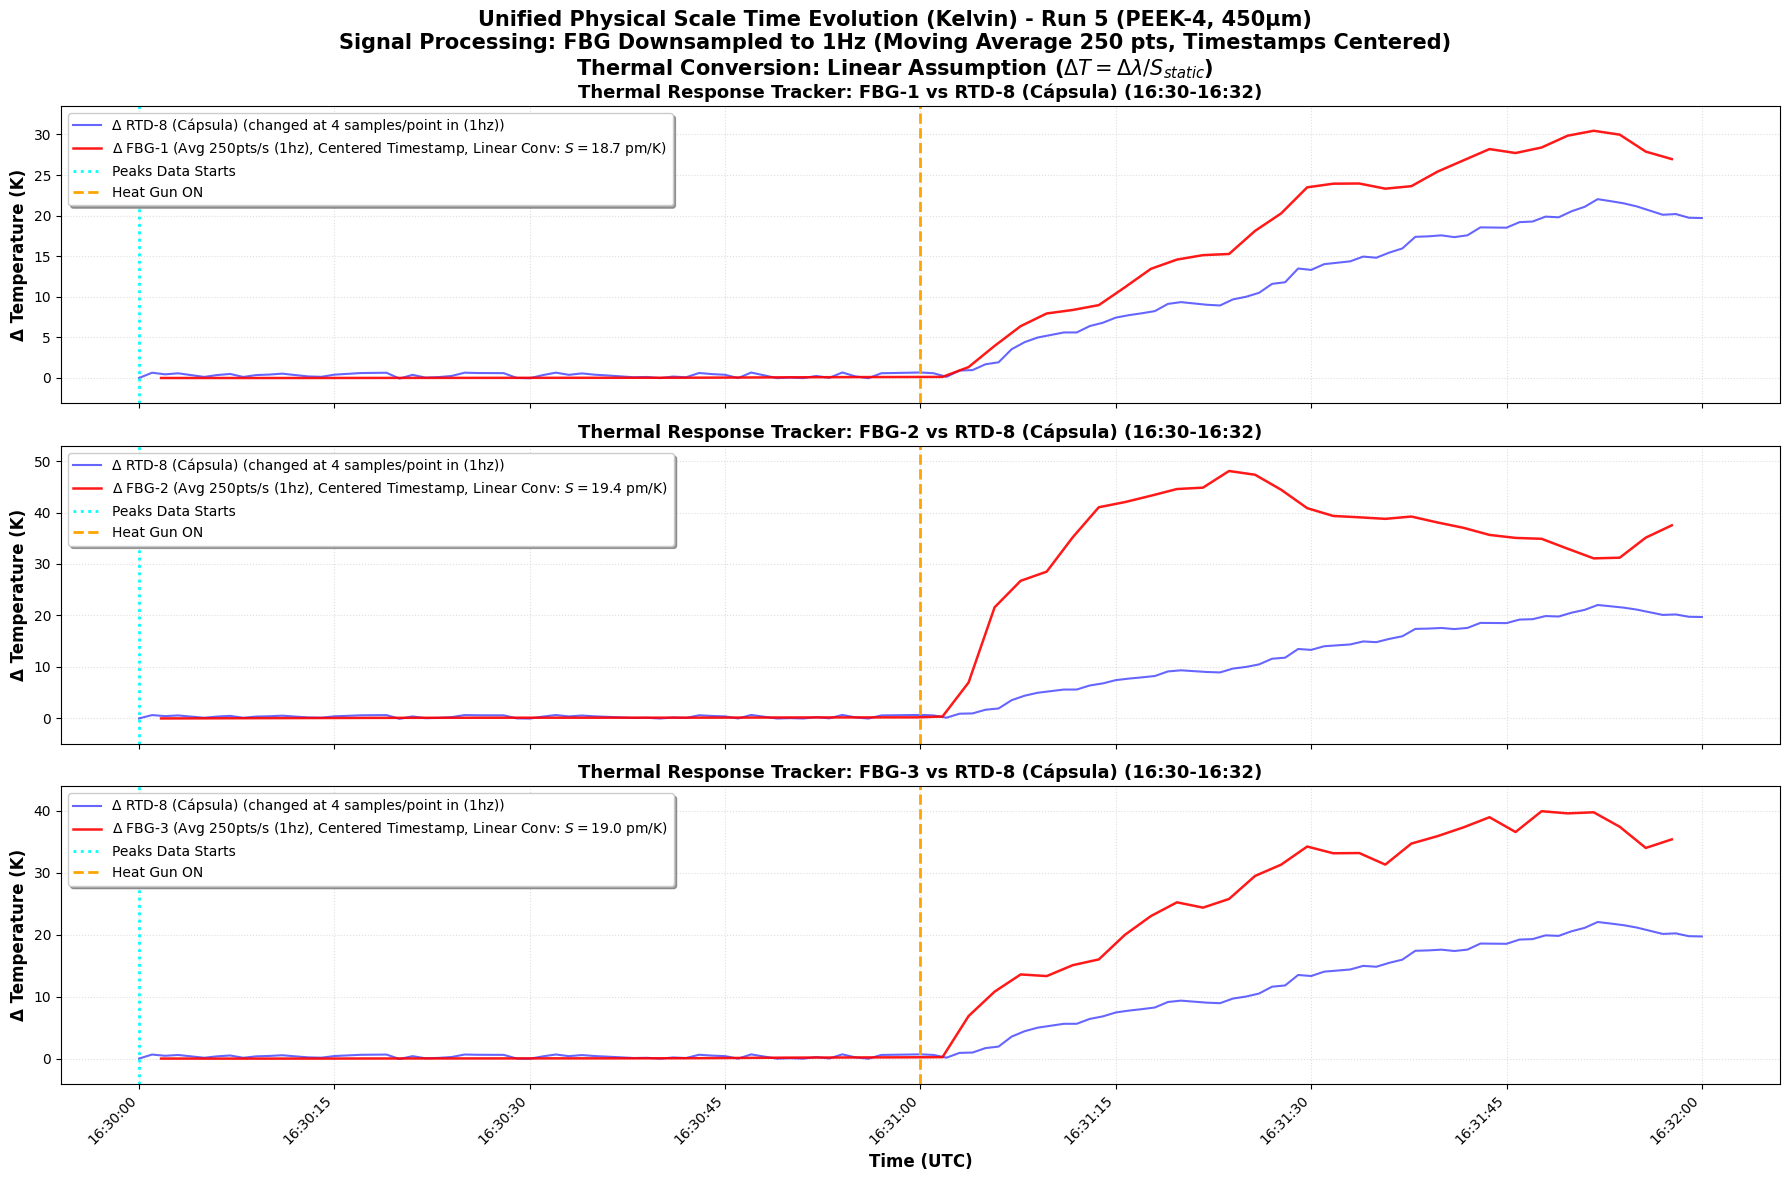

In [30]:
import datetime
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# CONFIGURATION: Filter by time range (16:28 - 17:00)
# ============================================================================
use_filtered_range_plot = True  # Change to True to filter by a specific range
# Asumimos que la variable 'fecha' ya existe en tu entorno de trabajo
# fecha = datetime.date(2026, 6, 17) 

if use_filtered_range_plot:
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(16, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(16, 32))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Full range)"

# ============================================================================
# TIMING EVENTS: Run 5 Configuration
# ============================================================================
event_temp_start = datetime.datetime.combine(fecha, datetime.time(16, 29, 30))
event_peaks_start = datetime.datetime.combine(fecha, datetime.time(16, 30, 0))
event_heat_on = datetime.datetime.combine(fecha, datetime.time(16, 31, 0))
event_heat_off = datetime.datetime.combine(fecha, datetime.time(16, 34, 0))
event_temp_end = datetime.datetime.combine(fecha, datetime.time(16, 36, 0))
event_peaks_end = datetime.datetime.combine(fecha, datetime.time(16, 36, 30))

# ============================================================================
# PHYSICAL PARAMETERS (Sensitivities in nm/K)
# ============================================================================
fbg_sensitivities_nm_K = {
    1: 18.669 * 1e-3,  # FBG-1: 18.669 pm/K
    2: 19.372 * 1e-3,  # FBG-2: 19.372 pm/K
    3: 19.000 * 1e-3,  # FBG-3: 19.000 pm/K
}

# ----------------------------------------------------------------------------
# DOWNSAMPLING PARAMETERS (Alineación temporal)
# ----------------------------------------------------------------------------
fbg_native_hz = 250
rtd_current_hz = 1.0  
ds_factor = int(fbg_native_hz / rtd_current_hz)  # 250 puntos por bloque
half_ds_factor = ds_factor // 2  # Usado para extraer el timestamp central
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# 1. PROCESS RTD REFERENCE DATA (At 1 Hz)
temp_raw_valid_mask = (
    (temp_raw[:, rtd_ref_idx] > 0)
    & (times_temp >= t_plot_inicio)
    & (times_temp <= t_plot_fin)
)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# Delta T from RTD
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp_K = temp_plot - temp_baseline

# 2. PROCESS EACH FBG SENSOR WITH DOWNSAMPLING TO 1 HZ
for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_sensitivity_nm_K = fbg_sensitivities_nm_K[sensor_num]

    # Extract complete RAW data
    sensor_idx = sensor_num - 1
    wav_p_full = wav_raw[:, 0, sensor_idx]
    wav_s_full = wav_raw[:, 1, sensor_idx]

    # Filter raw 250Hz peaks by time range
    mask_p = (
        (wav_p_full > 0)
        & (times_peak >= t_plot_inicio)
        & (times_peak <= t_plot_fin)
    )
    mask_s = (
        (wav_s_full > 0)
        & (times_peak >= t_plot_inicio)
        & (times_peak <= t_plot_fin)
    )

    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]

    # Interpolate Polarization S to P times
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)

    # Native Mean (P+S)/2 at 250 Hz
    wav_mean_raw = (wav_p_plot_valid + wav_s_interp_plot) / 2.0

    # ----------------------------------------------------------------------
    # APLICAR DOWNSAMPLING A 1 HZ (Promediando bloques de 250 puntos)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_raw) // ds_factor

    if num_blocks > 0:
        # Promedio del eje Y (Longitud de onda)
        wav_mean_plot_ds = np.mean(
            wav_mean_raw[: num_blocks * ds_factor].reshape(-1, ds_factor),
            axis=1,
        )
        # Selección del eje X (Timestamp exacto del centro del bloque)
        times_p_plot_ds = times_p_plot[
            half_ds_factor : num_blocks * ds_factor : ds_factor
        ]
    else:
        wav_mean_plot_ds = wav_mean_raw
        times_p_plot_ds = times_p_plot

    # Delta Wavelength calculation
    wav_baseline = wav_mean_plot_ds[0] if len(wav_mean_plot_ds) > 0 else 0
    delta_wav_nm = wav_mean_plot_ds - wav_baseline

    # DIRECT PHYSICAL CONVERSION TO KELVIN
    fbg_temp_equivalent_K = delta_wav_nm / fbg_sensitivity_nm_K

    ax = axes[idx]

    # Plot both signals on the unified axis
    ax.plot(
        times_temp_plot,
        delta_temp_K,
        "b-",
        linewidth=1.5,
        alpha=0.6,
        label=f"Δ {rtd_ref_name} (changed at 4 samples/point in (1hz))",
    )
    
    # Hemos modificado la leyenda para explicar explícitamente la matemática detrás
    sens_pm_K = fbg_sensitivity_nm_K * 1000 # Convertir a pm/K para leerse mejor
    ax.plot(
        times_p_plot_ds,
        fbg_temp_equivalent_K,
        "r-",
        linewidth=1.8,
        alpha=0.9,
        label=rf"Δ FBG-{sensor_num} (Avg 250pts/s (1hz), Centered Timestamp, Linear Conv: $S = {sens_pm_K:.1f}$ pm/K)",
    )

    ax.set_ylabel("Δ Temperature (K)", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.4, linestyle=':')

    # Draw vertical synchronization lines
    for ev_time, ev_col, ev_style, ev_lab in [
        (event_temp_start, "green", ":", "Temp Data Starts"),
        (event_peaks_start, "cyan", ":", "Peaks Data Starts"),
        (event_heat_on, "orange", "--", "Heat Gun ON"),
        (event_heat_off, "purple", "--", "Heat Gun OFF"),
    ]:
        if t_plot_inicio <= ev_time <= t_plot_fin:
            ax.axvline(x=ev_time, color=ev_col, linestyle=ev_style, linewidth=2, label=ev_lab)

    # UNIFIED DYNAMIC LIMITS
    if len(delta_temp_K) > 0 or len(fbg_temp_equivalent_K) > 0:
        all_values = np.concatenate([delta_temp_K, fbg_temp_equivalent_K])
        y_min, y_max = np.min(all_values), np.max(all_values)
        y_range = y_max - y_min if (y_max - y_min) > 0 else 1.0
        ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)

    ax.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)
    ax.set_title(f"Thermal Response Tracker: FBG-{sensor_num} vs {rtd_ref_name} {range_label}", fontsize=13, fontweight='bold')

# Configure X-axis
axes[-1].set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

# Título principal mucho más descriptivo sobre el procesamiento de la señal
plt.suptitle(
    "Unified Physical Scale Time Evolution (Kelvin) - Run 5 (PEEK-4, 450µm)\n"
    "Signal Processing: FBG Downsampled to 1Hz (Moving Average 250 pts, Timestamps Centered)\n"
    r"Thermal Conversion: Linear Assumption ($\Delta T = \Delta\lambda / S_{static}$)",
    fontsize=15,
    fontweight='bold',
    y=0.98,
)
plt.tight_layout()
plt.subplots_adjust(top=0.90) # Ajustar espacio para el gran título
plt.show()